# BUSINESS DATA ANALYTICS APPLIED LAB #2
## Risk Management & OSH Analytics - Marco CRISP-DM

**Integrantes:**  
Sara Valentina Guauque Zarrate  
Shady Alejandra Garay Rodriguez  
Sergio David Vargas Garzón

**Propósito:** consolidar las bases de trabajadores, empresas y accidentes; medir la tasa de accidentalidad; identificar patrones de riesgo; y proponer controles preventivos accionables para el ERP.

## Respuesta ejecutiva

El análisis integra 3.000 trabajadores, 150 empresas y 1.067 accidentes. La jornada nocturna presenta la mayor tasa (44,96%). En la noche, minería alcanza 65,62% y construcción 58,09%; el perfil de mayor riesgo con muestra suficiente es operativo nocturno en minería: 63,27%. El sistema de gestión muestra la brecha organizacional más importante: 57,62% sin implementación vs 31,10% con sistema.

Este notebook conserva las gráficas originales y añade cruces por capacitación, cargo, género, edad, antigüedad, hijos, tipo de empresa, gestión, sector, empresas, lesiones y perfiles combinados. Se distinguen cantidad de casos y tasa de accidentalidad.

## 1. Business Understanding

La gerencia necesita determinar qué condiciones laborales y organizacionales se asocian con una mayor proporción de trabajadores accidentados. Las preguntas centrales son:

1. ¿Cuál jornada presenta la mayor tasa de accidentalidad?
2. ¿La capacitación observada se relaciona con una reducción de incidentes?
3. ¿Qué sectores y perfiles requieren priorización?
4. ¿Las empresas con sistema de gestión muestran mejores resultados?
5. Dentro de la jornada nocturna, ¿qué nivel educativo y sector económico concentran mayor riesgo?

> **Definición del indicador:** tasa de accidentalidad = trabajadores con al menos un accidente / trabajadores expuestos en el grupo × 100. Esta tasa permite comparar grupos de tamaños distintos.

In [1]:
# Librerías y configuración visual
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

COLORES = {
    "azul": "#184E77",
    "azul_claro": "#52B6CB",
    "verde": "#2A9D8F",
    "amarillo": "#E9C46A",
    "naranja": "#F4A261",
    "rojo": "#E76F51",
    "gris": "#667085",
}

## 2. Data Understanding - carga y auditoría de calidad

El código busca los tres CSV en el directorio actual, en `/content` (Google Colab) o en una carpeta `data`. Si no los encuentra en Colab, solicita cargarlos. Luego elimina columnas índice exportadas por error (`Unnamed: ...`).

In [2]:
ARCHIVOS = ["trabajadores.csv", "empresas.csv", "accidentes.csv"]
candidatas = [Path.cwd(), Path("/content"), Path.cwd() / "data"]

carpeta_datos = next(
    (ruta for ruta in candidatas if all((ruta / archivo).exists() for archivo in ARCHIVOS)),
    None,
)

if carpeta_datos is None:
    try:
        from google.colab import files
        print("Sube trabajadores.csv, empresas.csv y accidentes.csv")
        files.upload()
        carpeta_datos = Path("/content")
    except ImportError as exc:
        raise FileNotFoundError(
            "No se encontraron los tres CSV. Ubícalos junto al notebook o en una carpeta data/."
        ) from exc

df_trabajadores = pd.read_csv(carpeta_datos / "trabajadores.csv")
df_empresas = pd.read_csv(carpeta_datos / "empresas.csv")
df_accidentes = pd.read_csv(carpeta_datos / "accidentes.csv")

for df in (df_trabajadores, df_empresas, df_accidentes):
    df.drop(columns=df.filter(regex=r"^Unnamed:").columns, inplace=True, errors="ignore")

print(f"Carpeta de datos: {carpeta_datos.resolve()}")
print(f"Trabajadores: {df_trabajadores.shape[0]:,} filas | Empresas: {df_empresas.shape[0]:,} filas | Accidentes: {df_accidentes.shape[0]:,} filas")

Carpeta de datos: /workspace/scratch/21077b06e181/work/input
Trabajadores: 3,000 filas | Empresas: 150 filas | Accidentes: 1,067 filas


In [3]:
auditoria = pd.DataFrame({
    "base": ["trabajadores", "empresas", "accidentes"],
    "filas": [len(df_trabajadores), len(df_empresas), len(df_accidentes)],
    "columnas": [df_trabajadores.shape[1], df_empresas.shape[1], df_accidentes.shape[1]],
    "nulos": [df_trabajadores.isna().sum().sum(), df_empresas.isna().sum().sum(), df_accidentes.isna().sum().sum()],
    "duplicados_llave": [
        df_trabajadores["id_trabajador"].duplicated().sum(),
        df_empresas["id_empresa"].duplicated().sum(),
        df_accidentes["id_accidente"].duplicated().sum(),
    ],
})

controles = {
    "Trabajadores sin empresa válida": int((~df_trabajadores["empresa"].isin(df_empresas["id_empresa"])).sum()),
    "Accidentes sin trabajador válido": int((~df_accidentes["id_trabajador"].isin(df_trabajadores["id_trabajador"])).sum()),
    "Trabajadores con más de un accidente registrado": int(df_accidentes["id_trabajador"].duplicated().sum()),
}

display(auditoria)
display(pd.DataFrame(controles.items(), columns=["control", "hallazgos"]))

assert auditoria["duplicados_llave"].eq(0).all(), "Existen llaves duplicadas."
assert all(valor == 0 for valor in controles.values()), "La integridad referencial requiere revisión."

,base,filas,columnas,nulos,duplicados_llave
0,trabajadores,3000,10,0,0
1,empresas,150,4,0,0
2,accidentes,1067,4,0,0


,control,hallazgos
0,Trabajadores sin empresa válida,0
1,Accidentes sin trabajador válido,0
2,Trabajadores con más de un accidente registrado,0


## 3. Data Preparation - triple join y tabla maestra

1. Se unen trabajadores y empresas mediante `empresa = id_empresa` con validación **muchos a uno**.
2. Los accidentes se resumen por trabajador y se incorporan con un **left join**, para conservar también a quienes no se accidentaron.
3. Se crea `incidente` (1/0), el número de accidentes y grupos consistentes de edad y antigüedad.

Aunque en esta base cada trabajador accidentado tiene un solo registro, el resumen previo hace que el flujo siga siendo válido si en el futuro aparecen varios accidentes por persona.

In [4]:
# Primer join: trabajadores + empresas
df_base = df_trabajadores.merge(
    df_empresas,
    left_on="empresa",
    right_on="id_empresa",
    how="left",
    validate="many_to_one",
)

# Resumen de accidentes a nivel trabajador
accidentes_trabajador = (
    df_accidentes.groupby("id_trabajador", as_index=False)
    .agg(
        numero_accidentes=("id_accidente", "nunique"),
        id_accidente=("id_accidente", "first"),
        parte_del_cuerpo=("parte_del_cuerpo", "first"),
        lesion=("lesion", "first"),
    )
)

# Segundo join: tabla base + accidentes (left join)
df_final = df_base.merge(
    accidentes_trabajador,
    on="id_trabajador",
    how="left",
    validate="one_to_one",
)

df_final["numero_accidentes"] = df_final["numero_accidentes"].fillna(0).astype(int)
df_final["incidente"] = (df_final["numero_accidentes"] > 0).astype(int)

df_final["grupo_edad"] = pd.cut(
    df_final["edad"],
    bins=[17, 25, 35, 45, 55, np.inf],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"],
    right=False,
)
df_final["grupo_antiguedad"] = pd.cut(
    df_final["antiguedad"],
    bins=[0, 3, 6, 11, 16, np.inf],
    labels=["0-2", "3-5", "6-10", "11-15", "16+"],
    right=False,
)

assert len(df_final) == len(df_trabajadores)
assert df_final["incidente"].isin([0, 1]).all()

print(f"Tabla maestra: {len(df_final):,} trabajadores y {df_final.shape[1]} variables")
print(f"Trabajadores accidentados: {df_final['incidente'].sum():,} | Tasa global: {df_final['incidente'].mean()*100:.2f}%")
display(df_final.head())

Tabla maestra: 3,000 trabajadores y 21 variables
Trabajadores accidentados: 1,067 | Tasa global: 35.57%


,id_trabajador,edad,genero,nivel_educativo,num_hijos,tipo_cargo,capacitado,jornada,antiguedad,empresa,id_empresa,sector_economico,tipo_empresa,sistema_gestion,numero_accidentes,id_accidente,parte_del_cuerpo,lesion,incidente,grupo_edad,grupo_antiguedad
0,1,31,masculino,bachiller,0,operativo,1,nocturna,19,70,70,agricultura,privada,1,0,NaN,NaN,NaN,0,25-34,16+
1,2,43,masculino,universitario,2,operativo,0,mixta,5,32,32,comercio,privada,1,0,NaN,NaN,NaN,0,35-44,3-5
2,3,27,masculino,tecnico,1,operativo,0,diurna,7,120,120,construccion,privada,1,1,1.00,espalda,luxacion,1,25-34,6-10
3,4,64,femenino,bachiller,1,operativo,1,diurna,8,98,98,manufactura,privada,1,0,NaN,NaN,NaN,0,55+,6-10
4,5,45,masculino,maestria,1,administrativo,1,nocturna,6,49,49,salud,privada,1,1,2.00,ojo,lesiones multiples,1,45-54,6-10


In [5]:
def intervalo_wilson(accidentados, trabajadores, z=1.96):
    # Intervalo de confianza Wilson del 95% para una proporción.
    if trabajadores == 0:
        return np.nan, np.nan
    p = accidentados / trabajadores
    denom = 1 + z**2 / trabajadores
    centro = (p + z**2 / (2 * trabajadores)) / denom
    margen = z * math.sqrt((p * (1 - p) + z**2 / (4 * trabajadores)) / trabajadores) / denom
    return 100 * (centro - margen), 100 * (centro + margen)


def tabla_riesgo(datos, variable):
    tabla = (
        datos.groupby(variable, observed=True, dropna=False)
        .agg(
            trabajadores=("id_trabajador", "nunique"),
            accidentados=("incidente", "sum"),
            accidentes=("numero_accidentes", "sum"),
        )
        .reset_index()
    )
    tabla["tasa_pct"] = 100 * tabla["accidentados"] / tabla["trabajadores"]
    tabla["participacion_accidentes_pct"] = 100 * tabla["accidentes"] / tabla["accidentes"].sum()
    limites = tabla.apply(
        lambda fila: intervalo_wilson(fila["accidentados"], fila["trabajadores"]),
        axis=1,
        result_type="expand",
    )
    tabla[["ic95_inf", "ic95_sup"]] = limites
    return tabla.sort_values(["tasa_pct", "accidentados"], ascending=False).reset_index(drop=True)


def mostrar_tabla(tabla, nombre):
    print(nombre)
    formateada = tabla.copy()
    for columna in ["tasa_pct", "participacion_accidentes_pct", "ic95_inf", "ic95_sup"]:
        if columna in formateada.columns:
            formateada[columna] = formateada[columna].map(lambda valor: f"{valor:.2f}%")
    display(formateada)


def grafica_tasa(ax, tabla, categoria, titulo, horizontal=False, color="#184E77", mostrar_n=True):
    datos = tabla.copy()
    if horizontal:
        datos = datos.sort_values("tasa_pct", ascending=True)
        barras = ax.barh(datos[categoria].astype(str), datos["tasa_pct"], color=color)
        limite = max(datos["tasa_pct"].max() * 1.28, 10)
        ax.set_xlim(0, limite)
        for barra, (_, fila) in zip(barras, datos.iterrows()):
            etiqueta = f"{fila['tasa_pct']:.1f}%"
            if mostrar_n:
                etiqueta += f"  ({int(fila['accidentados'])}/{int(fila['trabajadores'])})"
            ax.text(barra.get_width() + limite * 0.015, barra.get_y() + barra.get_height()/2, etiqueta, va="center", fontsize=8)
        ax.set_xlabel("Tasa de accidentalidad (%)")
        ax.set_ylabel("")
    else:
        barras = ax.bar(datos[categoria].astype(str), datos["tasa_pct"], color=color)
        limite = max(datos["tasa_pct"].max() * 1.22, 10)
        ax.set_ylim(0, limite)
        for barra, (_, fila) in zip(barras, datos.iterrows()):
            etiqueta = f"{fila['tasa_pct']:.1f}%"
            if mostrar_n:
                etiqueta += f"\nn={int(fila['trabajadores'])}"
            ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + limite*0.02, etiqueta, ha="center", va="bottom", fontsize=8)
        ax.set_ylabel("Tasa de accidentalidad (%)")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)
    ax.set_title(titulo, loc="left", fontweight="bold")
    ax.grid(axis="y" if not horizontal else "x", alpha=0.25)
    sns.despine(ax=ax)

## 4. Modelado descriptivo - evidencia base solicitada

Las tablas reportan simultáneamente exposición, casos, tasa, participación e intervalo de confianza. Esto evita confundir un grupo grande con uno necesariamente más riesgoso.

In [6]:
tabla_jornada = tabla_riesgo(df_final, "jornada")
tabla_capacitacion = tabla_riesgo(df_final, "capacitado")
tabla_capacitacion["capacitado"] = tabla_capacitacion["capacitado"].map({0: "No", 1: "Sí"})
tabla_sector = tabla_riesgo(df_final, "sector_economico")

mostrar_tabla(tabla_jornada, "Tasa de accidentalidad por jornada")
mostrar_tabla(tabla_capacitacion, "Tasa de accidentalidad por capacitación")
mostrar_tabla(tabla_sector, "Tasa de accidentalidad por sector económico")

Tasa de accidentalidad por jornada
Tasa de accidentalidad por capacitación
Tasa de accidentalidad por sector económico


,jornada,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,nocturna,685,308,308,44.96%,28.87%,41.28%,48.71%
1,mixta,548,189,189,34.49%,17.71%,30.63%,38.56%
2,diurna,1767,570,570,32.26%,53.42%,30.12%,34.47%


,capacitado,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,Sí,1279,533,533,41.67%,49.95%,39.00%,44.40%
1,No,1721,534,534,31.03%,50.05%,28.89%,33.25%


,sector_economico,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,mineria,242,120,120,49.59%,11.25%,43.34%,55.84%
1,construccion,650,316,316,48.62%,29.62%,44.79%,52.45%
2,manufactura,408,134,134,32.84%,12.56%,28.46%,37.54%
3,educacion,99,32,32,32.32%,3.00%,23.92%,42.05%
4,funcion publica,91,29,29,31.87%,2.72%,23.20%,42.01%
5,comercio,207,64,64,30.92%,6.00%,25.02%,37.51%
6,alimentos,471,140,140,29.72%,13.12%,25.77%,34.00%
7,salud,168,49,49,29.17%,4.59%,22.82%,36.44%
8,servicios,314,91,91,28.98%,8.53%,24.24%,34.23%
9,agricultura,350,92,92,26.29%,8.62%,21.95%,31.14%


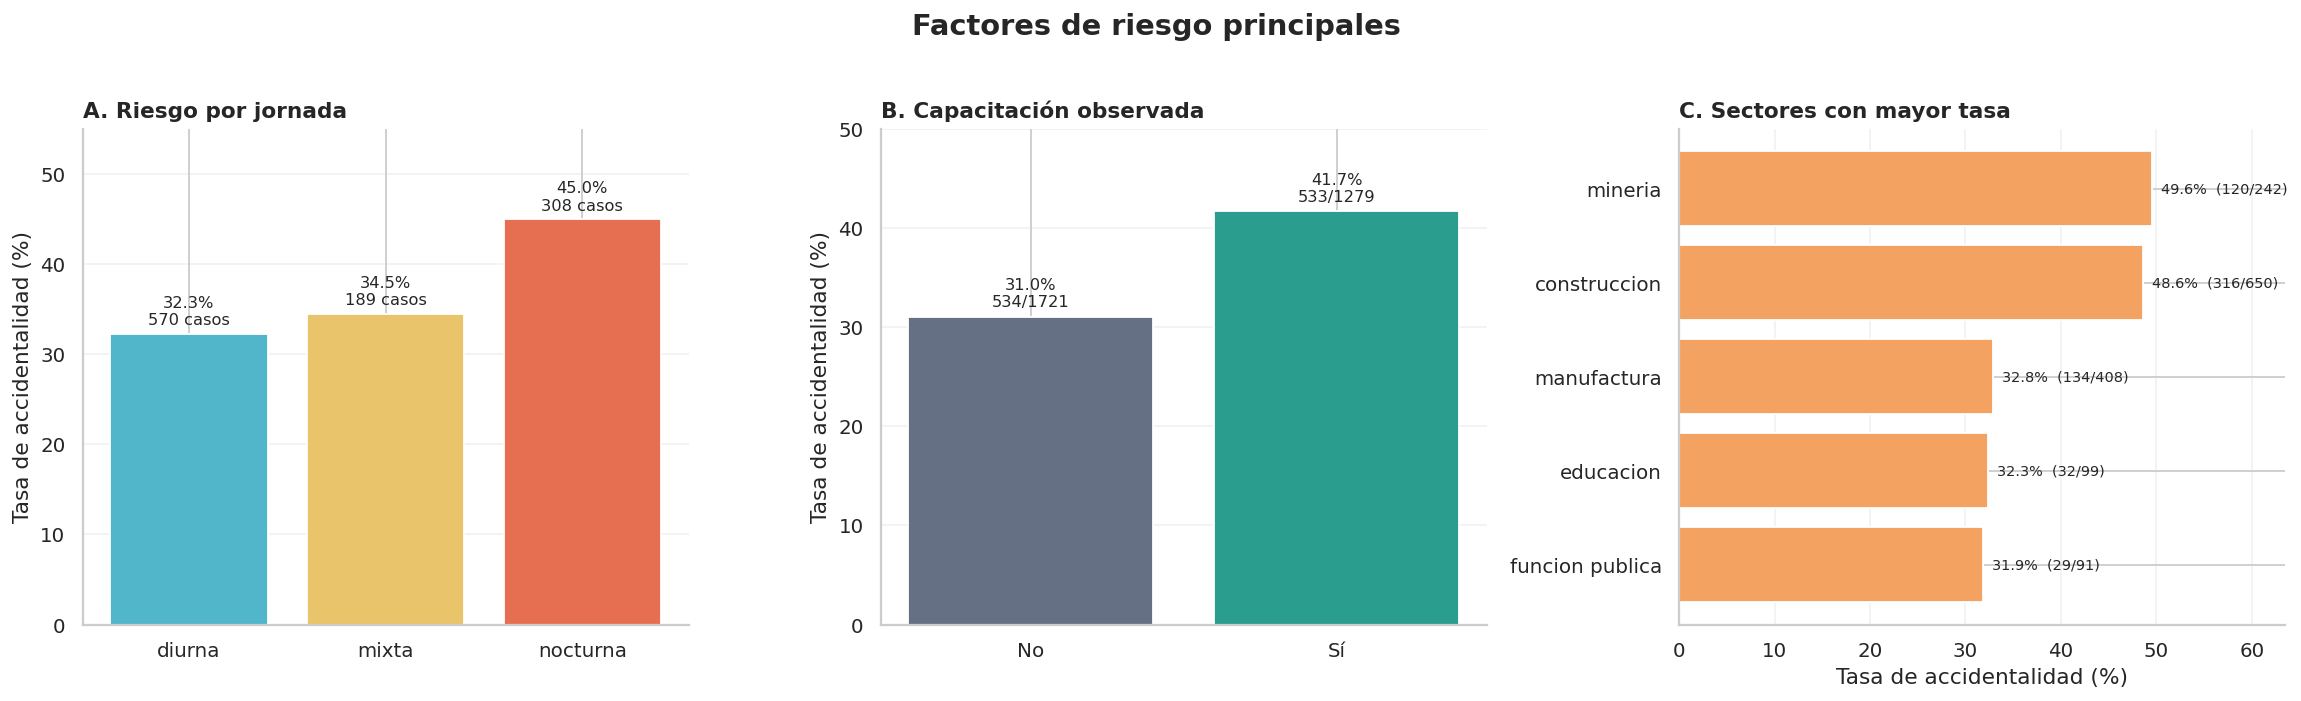

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.3))

orden_jornada = ["diurna", "mixta", "nocturna"]
tj = tabla_jornada.set_index("jornada").loc[orden_jornada].reset_index()
colores_jornada = [COLORES["azul_claro"], COLORES["amarillo"], COLORES["rojo"]]
barras = axes[0].bar(tj["jornada"], tj["tasa_pct"], color=colores_jornada)
axes[0].set_ylim(0, 55)
axes[0].set_ylabel("Tasa de accidentalidad (%)")
axes[0].set_title("A. Riesgo por jornada", loc="left", fontweight="bold")
for b, (_, f) in zip(barras, tj.iterrows()):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{f['tasa_pct']:.1f}%\n{int(f['accidentados'])} casos", ha="center", fontsize=9)

tc = tabla_capacitacion.set_index("capacitado").loc[["No", "Sí"]].reset_index()
barras = axes[1].bar(tc["capacitado"], tc["tasa_pct"], color=[COLORES["gris"], COLORES["verde"]])
axes[1].set_ylim(0, 50)
axes[1].set_ylabel("Tasa de accidentalidad (%)")
axes[1].set_title("B. Capacitación observada", loc="left", fontweight="bold")
for b, (_, f) in zip(barras, tc.iterrows()):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{f['tasa_pct']:.1f}%\n{int(f['accidentados'])}/{int(f['trabajadores'])}", ha="center", fontsize=9)

top5 = tabla_sector.head(5)
grafica_tasa(axes[2], top5, "sector_economico", "C. Sectores con mayor tasa", horizontal=True, color=COLORES["naranja"])

for ax in axes[:2]:
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

plt.suptitle("Factores de riesgo principales", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de la evidencia base

- **Jornada:** la nocturna tiene la mayor tasa (**44,96%**), seguida de la mixta (**34,49%**) y la diurna (**32,26%**). El riesgo nocturno es 12,70 puntos porcentuales superior al diurno. Sin embargo, la diurna reúne más casos absolutos (570) por su mayor dotación.
- **Capacitación:** los capacitados presentan una tasa observada mayor (**41,67%**) que los no capacitados (**31,03%**). Esto **no permite afirmar que capacitar cause accidentes**: pueden capacitarse con mayor frecuencia precisamente los cargos o sectores más peligrosos. El hallazgo indica que, con estos datos, la capacitación vigente no demuestra un efecto preventivo y debe evaluarse con mediciones antes/después y control por exposición.
- **Sector:** minería (**49,59%**) y construcción (**48,62%**) lideran la tasa global. Construcción también concentra el mayor volumen sectorial: 316 accidentados.

## 5. Exploración autónoma - sistema de gestión y perfiles

Se amplía el análisis a variables organizacionales y demográficas. Estas asociaciones son útiles para priorizar intervenciones, pero no prueban causalidad por sí solas.

Detalle del sistema de gestión
Detalle por tipo de cargo


,sistema_gestion,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,No implementado,505,291,291,57.62%,27.27%,53.27%,61.86%
1,Implementado,2495,776,776,31.10%,72.73%,29.32%,32.95%


,tipo_cargo,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,operativo,2290,862,862,37.64%,80.79%,35.68%,39.65%
1,administrativo,710,205,205,28.87%,19.21%,25.66%,32.31%


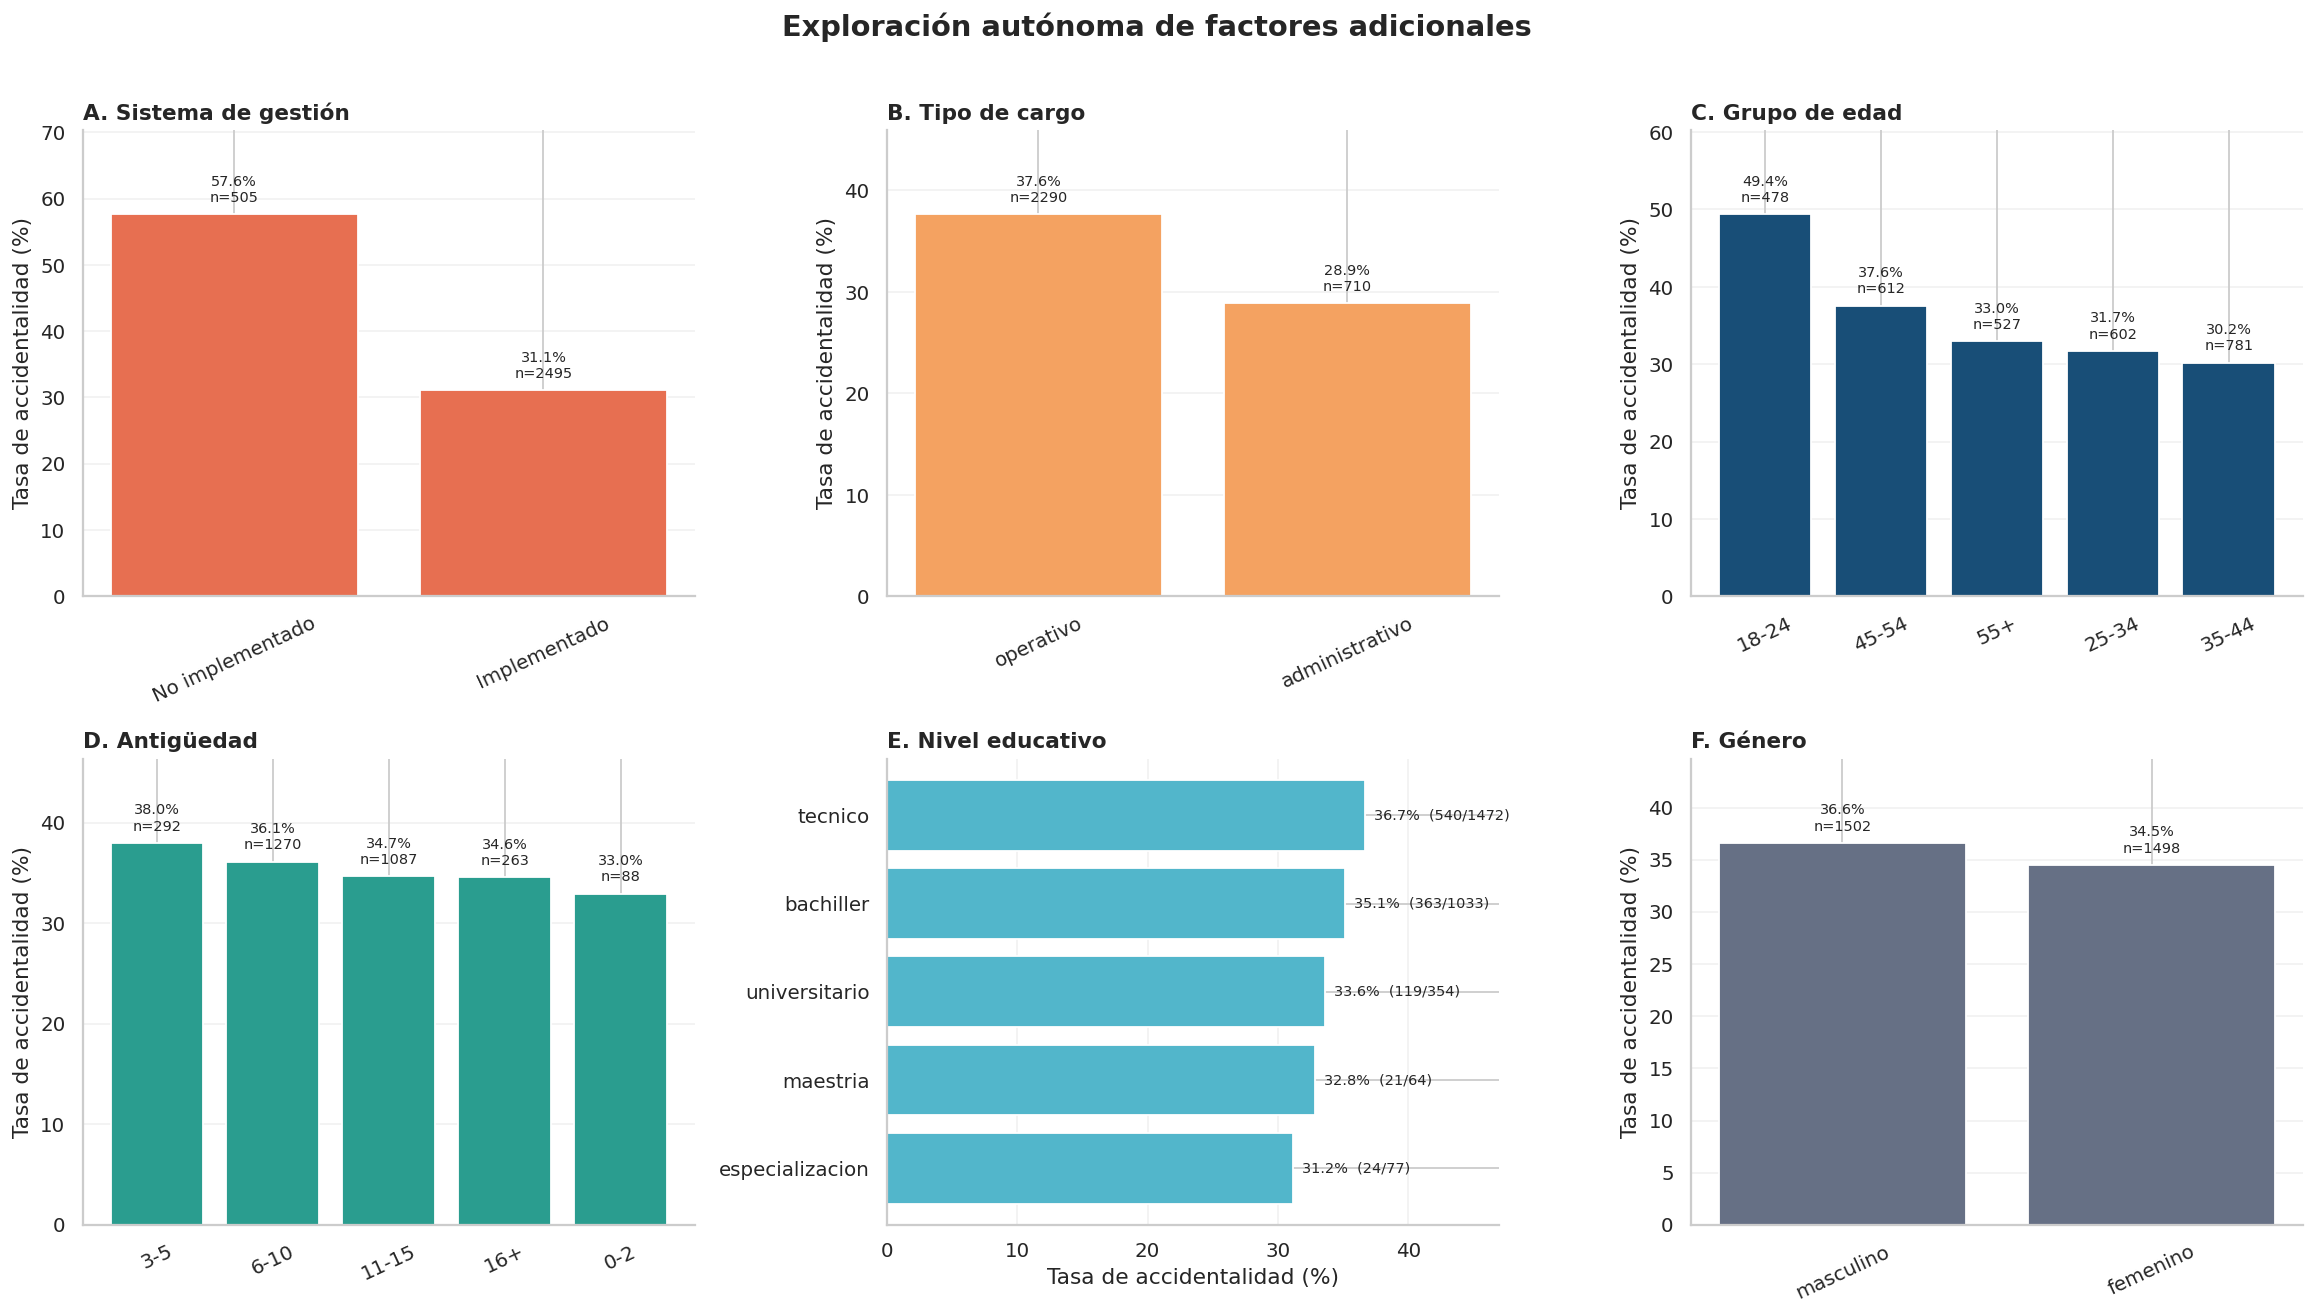

In [8]:
tabla_sistema = tabla_riesgo(df_final, "sistema_gestion")
tabla_sistema["sistema_gestion"] = tabla_sistema["sistema_gestion"].map({0: "No implementado", 1: "Implementado"})
tabla_cargo = tabla_riesgo(df_final, "tipo_cargo")
tabla_edad = tabla_riesgo(df_final, "grupo_edad")
tabla_antiguedad = tabla_riesgo(df_final, "grupo_antiguedad")
tabla_educacion = tabla_riesgo(df_final, "nivel_educativo")
tabla_genero = tabla_riesgo(df_final, "genero")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
grafica_tasa(axes[0,0], tabla_sistema, "sistema_gestion", "A. Sistema de gestión", color=COLORES["rojo"])
grafica_tasa(axes[0,1], tabla_cargo, "tipo_cargo", "B. Tipo de cargo", color=COLORES["naranja"])
grafica_tasa(axes[0,2], tabla_edad, "grupo_edad", "C. Grupo de edad", color=COLORES["azul"])
grafica_tasa(axes[1,0], tabla_antiguedad, "grupo_antiguedad", "D. Antigüedad", color=COLORES["verde"])
grafica_tasa(axes[1,1], tabla_educacion, "nivel_educativo", "E. Nivel educativo", horizontal=True, color=COLORES["azul_claro"])
grafica_tasa(axes[1,2], tabla_genero, "genero", "F. Género", color=COLORES["gris"])

plt.suptitle("Exploración autónoma de factores adicionales", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

mostrar_tabla(tabla_sistema, "Detalle del sistema de gestión")
mostrar_tabla(tabla_cargo, "Detalle por tipo de cargo")

### Hallazgos adicionales

- La ausencia de sistema de gestión presenta la brecha más clara: **57,62%** sin implementación frente a **31,10%** con implementación (26,52 puntos porcentuales).
- Los cargos operativos registran **37,64%** y concentran **862 casos (80,79% del total)**.
- El grupo de **18 a 24 años** tiene la mayor tasa por edad (**47,34%**).
- La antigüedad muestra diferencias más moderadas; el grupo de 3 a 5 años alcanza **38,01%**.
- Género y tipo de empresa presentan diferencias pequeñas; por tanto, no deben ser los principales criterios de priorización.

### 5.1 Capacitación combinada con jornada, cargo y sector

Esta sección conserva y mejora la gráfica original de capacitación por jornada. Además, controla descriptivamente por cargo y sector. Las etiquetas representan tasas, no cantidades absolutas.

,jornada,capacitado,trabajadores,accidentados,tasa_pct
0,diurna,No,1006,285,28.33
1,diurna,Sí,761,285,37.45
2,mixta,No,319,91,28.53
3,mixta,Sí,229,98,42.79
4,nocturna,No,396,158,39.90
5,nocturna,Sí,289,150,51.90


,tipo_cargo,capacitado,trabajadores,accidentados,tasa_pct
0,administrativo,No,424,106,25.00
1,administrativo,Sí,286,99,34.62
2,operativo,No,1297,428,33.00
3,operativo,Sí,993,434,43.71


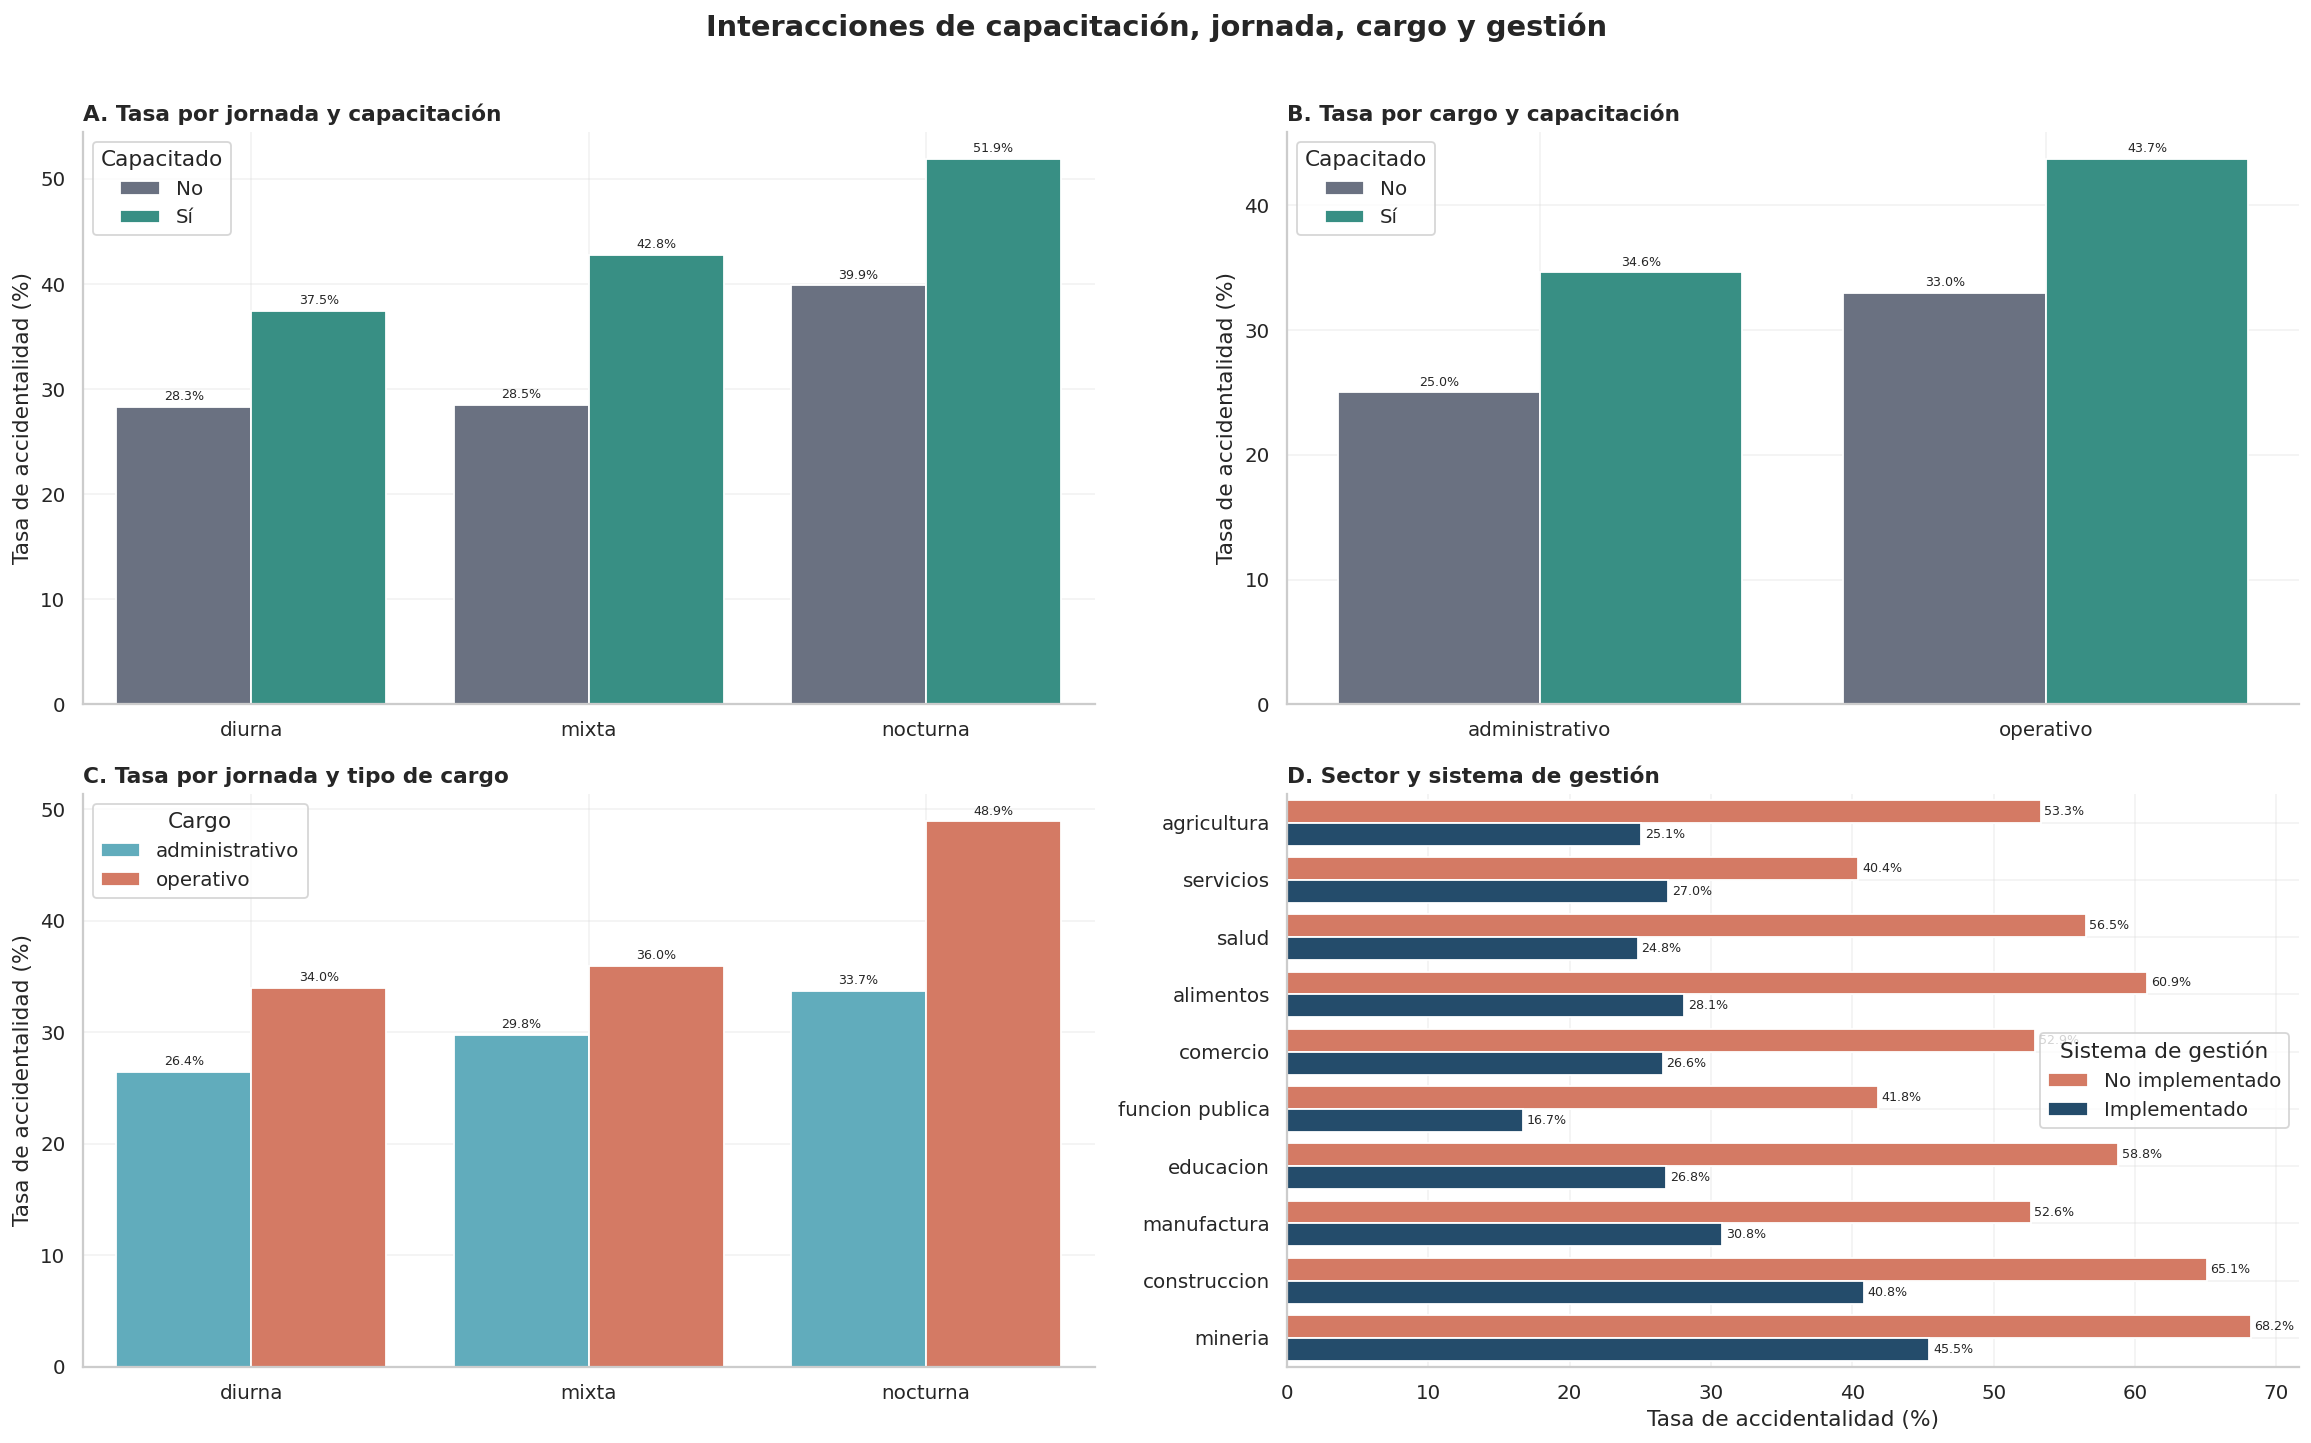

In [9]:
def tabla_cruzada(datos, variables):
    tabla = (
        datos.groupby(variables, observed=True)
        .agg(trabajadores=("id_trabajador", "nunique"), accidentados=("incidente", "sum"))
        .reset_index()
    )
    tabla["tasa_pct"] = 100 * tabla["accidentados"] / tabla["trabajadores"]
    return tabla


def anotar_barras(ax, horizontal=False):
    for contenedor in ax.containers:
        etiquetas = []
        for barra in contenedor:
            valor = barra.get_width() if horizontal else barra.get_height()
            etiquetas.append("" if not np.isfinite(valor) else f"{valor:.1f}%")
        ax.bar_label(contenedor, labels=etiquetas, padding=2, fontsize=7)


cruce_jornada_cap = tabla_cruzada(df_final, ["jornada", "capacitado"])
cruce_jornada_cap["capacitado"] = cruce_jornada_cap["capacitado"].map({0: "No", 1: "Sí"})
cruce_cargo_cap = tabla_cruzada(df_final, ["tipo_cargo", "capacitado"])
cruce_cargo_cap["capacitado"] = cruce_cargo_cap["capacitado"].map({0: "No", 1: "Sí"})
cruce_jornada_cargo = tabla_cruzada(df_final, ["jornada", "tipo_cargo"])
cruce_sector_sg = tabla_cruzada(df_final, ["sector_economico", "sistema_gestion"])
cruce_sector_sg["sistema_gestion"] = cruce_sector_sg["sistema_gestion"].map({0: "No implementado", 1: "Implementado"})

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.barplot(
    data=cruce_jornada_cap, x="jornada", y="tasa_pct", hue="capacitado",
    order=["diurna", "mixta", "nocturna"], palette=["#667085", "#2A9D8F"], ax=axes[0, 0]
)
axes[0, 0].set_title("A. Tasa por jornada y capacitación", loc="left", fontweight="bold")
axes[0, 0].set_ylabel("Tasa de accidentalidad (%)")
axes[0, 0].set_xlabel("")
axes[0, 0].legend(title="Capacitado")
anotar_barras(axes[0, 0])

sns.barplot(
    data=cruce_cargo_cap, x="tipo_cargo", y="tasa_pct", hue="capacitado",
    palette=["#667085", "#2A9D8F"], ax=axes[0, 1]
)
axes[0, 1].set_title("B. Tasa por cargo y capacitación", loc="left", fontweight="bold")
axes[0, 1].set_ylabel("Tasa de accidentalidad (%)")
axes[0, 1].set_xlabel("")
axes[0, 1].legend(title="Capacitado")
anotar_barras(axes[0, 1])

sns.barplot(
    data=cruce_jornada_cargo, x="jornada", y="tasa_pct", hue="tipo_cargo",
    order=["diurna", "mixta", "nocturna"], palette=["#52B6CB", "#E76F51"], ax=axes[1, 0]
)
axes[1, 0].set_title("C. Tasa por jornada y tipo de cargo", loc="left", fontweight="bold")
axes[1, 0].set_ylabel("Tasa de accidentalidad (%)")
axes[1, 0].set_xlabel("")
axes[1, 0].legend(title="Cargo")
anotar_barras(axes[1, 0])

orden_sector = tabla_sector["sector_economico"].tolist()[::-1]
sns.barplot(
    data=cruce_sector_sg, y="sector_economico", x="tasa_pct", hue="sistema_gestion",
    order=orden_sector, palette=["#E76F51", "#184E77"], ax=axes[1, 1]
)
axes[1, 1].set_title("D. Sector y sistema de gestión", loc="left", fontweight="bold")
axes[1, 1].set_xlabel("Tasa de accidentalidad (%)")
axes[1, 1].set_ylabel("")
axes[1, 1].legend(title="Sistema de gestión")
anotar_barras(axes[1, 1], horizontal=True)

for ax in axes.flat:
    ax.grid(alpha=0.22)
    sns.despine(ax=ax)
plt.suptitle("Interacciones de capacitación, jornada, cargo y gestión", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

display(cruce_jornada_cap)
display(cruce_cargo_cap)

La mayor tasa del cruce jornada-capacitación aparece en trabajadores nocturnos capacitados (51,90%). El segmento más crítico del cruce jornada-cargo-capacitación son los operativos nocturnos capacitados: 57,48% (123/214). Esto no prueba que la capacitación aumente el riesgo; puede reflejar formación dirigida a personas ya expuestas o un programa que aún no logra el efecto esperado.

### 5.2 Antigüedad exacta, hijos y variables complementarias

Se incluyen las visualizaciones del notebook anterior y se añaden variables no exploradas. El número de hijos se analiza únicamente como descripción y no debe convertirse en una regla de selección laboral.

Detalle por año de antigüedad
Detalle por número de hijos
Detalle por tipo de empresa


,antiguedad,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
21,0,22,4,4,18.18%,0.37%,7.31%,38.52%
1,1,22,10,10,45.45%,0.94%,26.92%,65.34%
15,2,44,15,15,34.09%,1.41%,21.88%,48.86%
5,3,59,23,23,38.98%,2.16%,27.58%,51.73%
16,4,92,31,31,33.70%,2.91%,24.86%,43.83%
2,5,141,57,57,40.43%,5.34%,32.68%,48.68%
10,6,194,70,70,36.08%,6.56%,29.66%,43.05%
11,7,208,73,73,35.10%,6.84%,28.93%,41.80%
6,8,273,105,105,38.46%,9.84%,32.89%,44.35%
8,9,285,105,105,36.84%,9.84%,31.45%,42.58%


,num_hijos,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,0,945,441,441,46.67%,41.33%,43.51%,49.85%
3,1,899,272,272,30.26%,25.49%,27.34%,33.34%
2,2,644,195,195,30.28%,18.28%,26.86%,33.94%
1,3,361,116,116,32.13%,10.87%,27.53%,37.12%
4,4,120,35,35,29.17%,3.28%,21.78%,37.84%
5,5,31,8,8,25.81%,0.75%,13.70%,43.25%


,tipo_empresa,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,publica,315,114,114,36.19%,10.68%,31.08%,41.63%
1,privada,2685,953,953,35.49%,89.32%,33.71%,37.32%


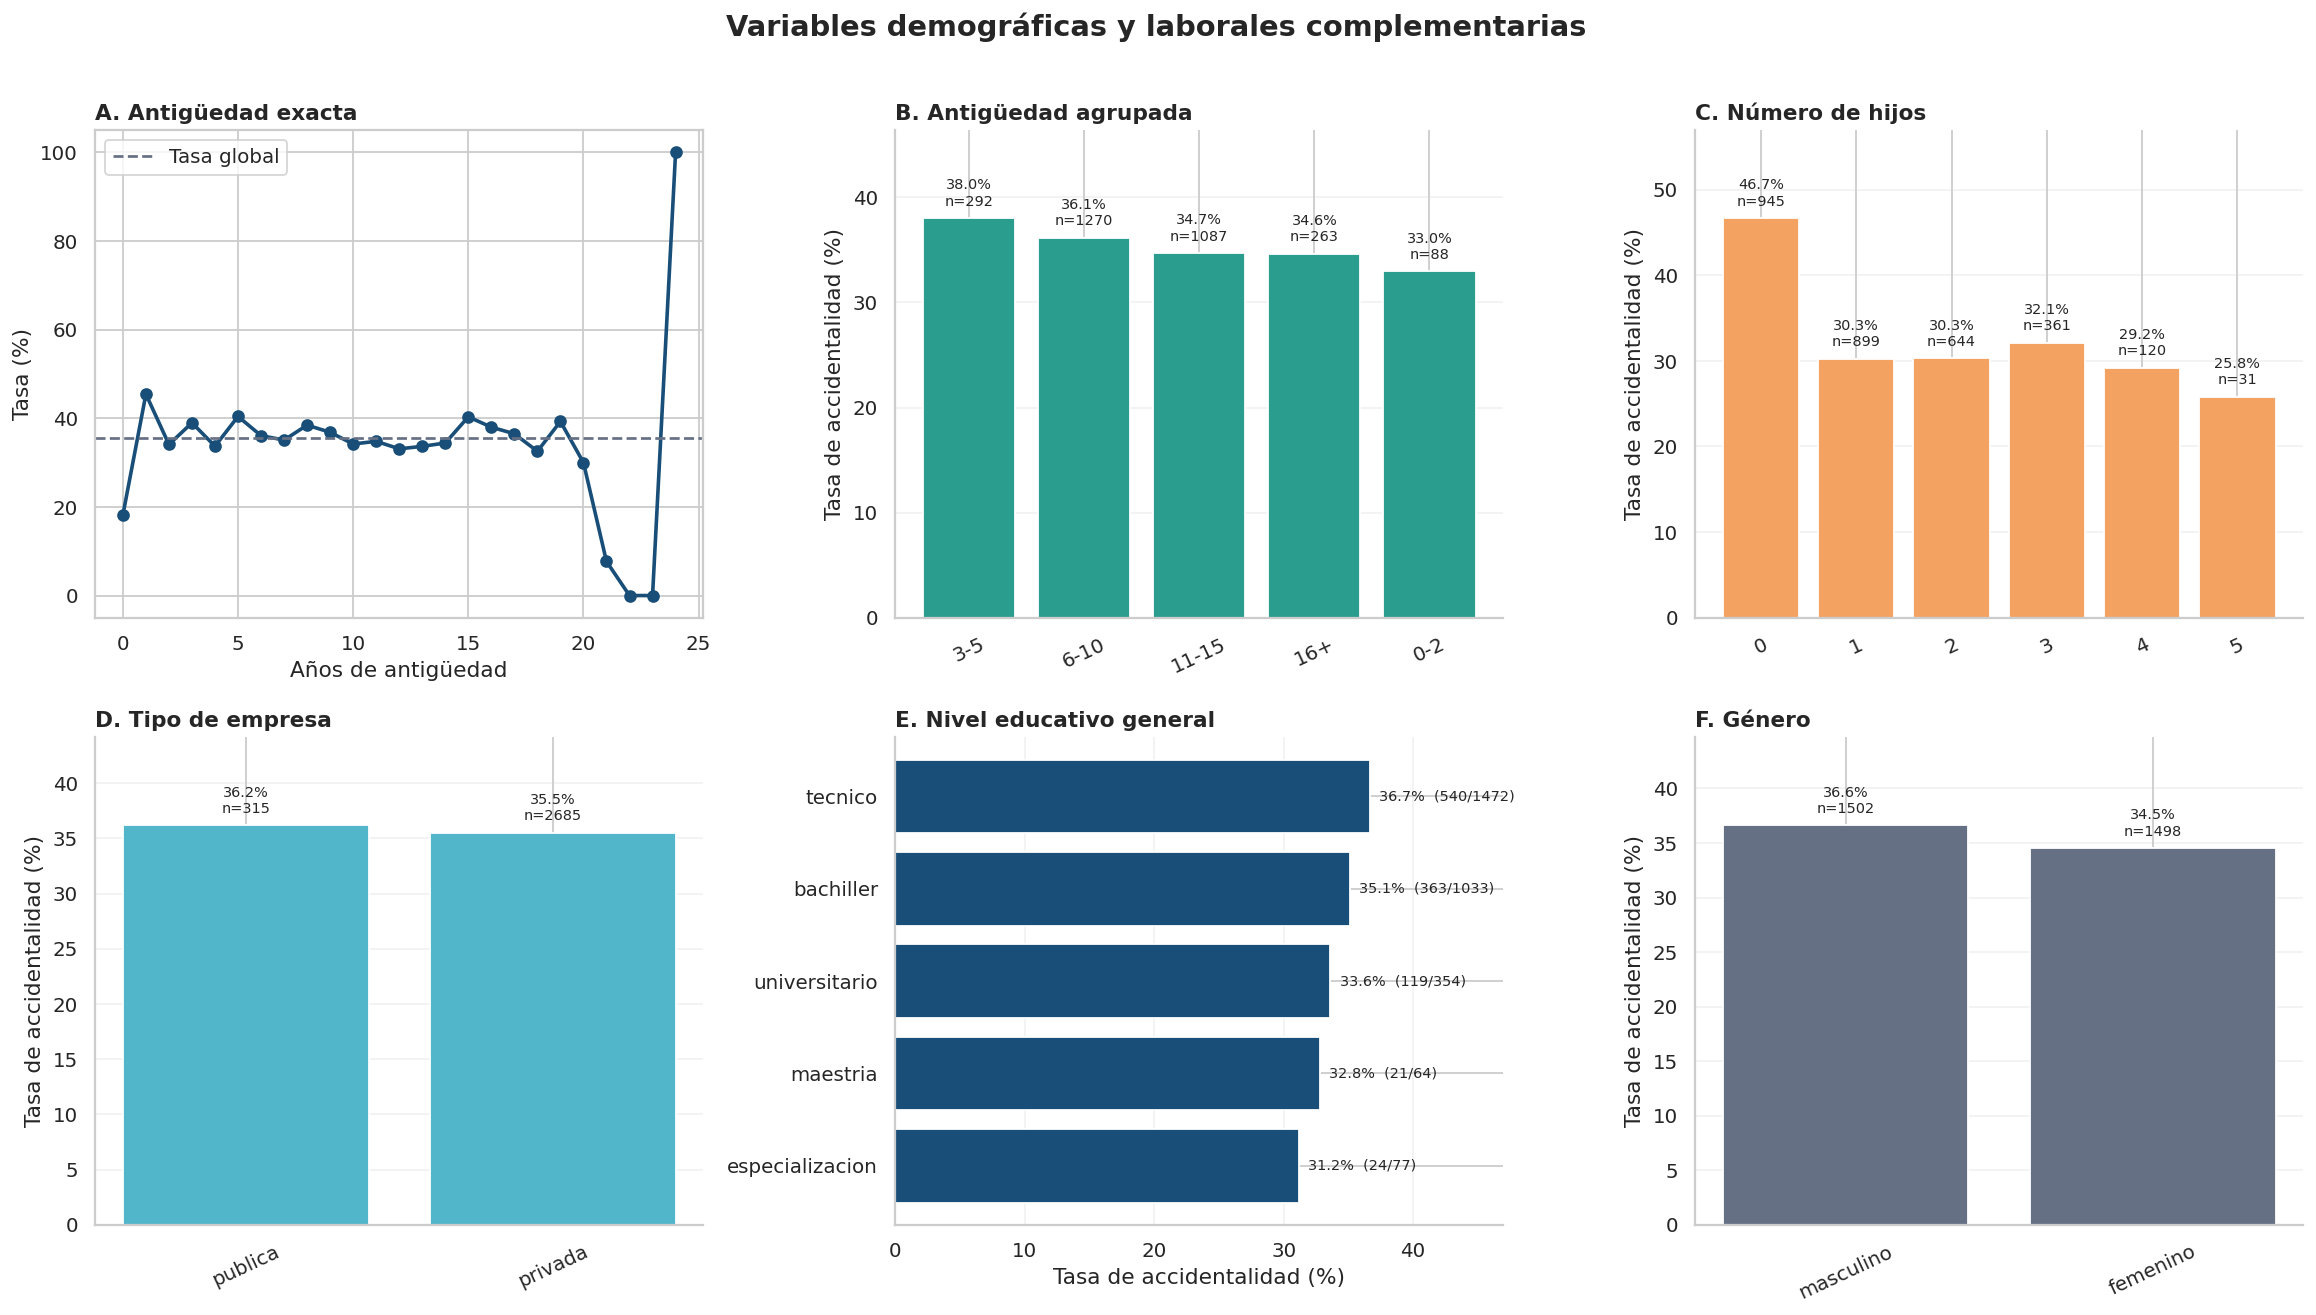

In [10]:
tabla_antiguedad_exacta = tabla_riesgo(df_final, "antiguedad").sort_values("antiguedad")
tabla_hijos = tabla_riesgo(df_final, "num_hijos").sort_values("num_hijos")
tabla_tipo_empresa = tabla_riesgo(df_final, "tipo_empresa")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].plot(
    tabla_antiguedad_exacta["antiguedad"], tabla_antiguedad_exacta["tasa_pct"],
    marker="o", linewidth=2, color=COLORES["azul"]
)
axes[0, 0].axhline(df_final["incidente"].mean()*100, color=COLORES["gris"], linestyle="--", label="Tasa global")
axes[0, 0].set_title("A. Antigüedad exacta", loc="left", fontweight="bold")
axes[0, 0].set_xlabel("Años de antigüedad")
axes[0, 0].set_ylabel("Tasa (%)")
axes[0, 0].legend()

grafica_tasa(axes[0, 1], tabla_antiguedad, "grupo_antiguedad", "B. Antigüedad agrupada", color=COLORES["verde"])
grafica_tasa(axes[0, 2], tabla_hijos, "num_hijos", "C. Número de hijos", color=COLORES["naranja"])
grafica_tasa(axes[1, 0], tabla_tipo_empresa, "tipo_empresa", "D. Tipo de empresa", color=COLORES["azul_claro"])
grafica_tasa(axes[1, 1], tabla_educacion, "nivel_educativo", "E. Nivel educativo general", horizontal=True, color=COLORES["azul"])
grafica_tasa(axes[1, 2], tabla_genero, "genero", "F. Género", color=COLORES["gris"])

plt.suptitle("Variables demográficas y laborales complementarias", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

mostrar_tabla(tabla_antiguedad_exacta, "Detalle por año de antigüedad")
mostrar_tabla(tabla_hijos, "Detalle por número de hijos")
mostrar_tabla(tabla_tipo_empresa, "Detalle por tipo de empresa")

- La antigüedad no muestra un patrón monotónico; los grupos consolidados son similares.
- Quienes reportan cero hijos presentan 46,67% (441/945), pero esta relación puede estar confundida por edad, cargo o jornada y no debe alimentar decisiones automatizadas.
- Las empresas públicas y privadas presentan tasas cercanas: 36,19% y 35,49%.
- Género y nivel educativo general muestran diferencias pequeñas y no concluyentes.

### 5.3 Evaluación por empresa

Como no existen nombres empresariales, se usa id_empresa. El ranking exige al menos 15 trabajadores para reducir la inestabilidad de muestras muy pequeñas.

,id_empresa,sector_economico,sistema_gestion,trabajadores,accidentados,tasa_pct
0,35,mineria,No implementado,21,19,90.48
1,97,construccion,No implementado,19,16,84.21
2,140,construccion,No implementado,27,21,77.78
3,131,construccion,No implementado,28,21,75.00
4,92,construccion,No implementado,30,21,70.00
5,117,comercio,No implementado,21,13,61.90
6,14,alimentos,No implementado,23,14,60.87
7,75,construccion,No implementado,27,16,59.26
8,12,mineria,Implementado,17,10,58.82
9,50,educacion,No implementado,17,10,58.82


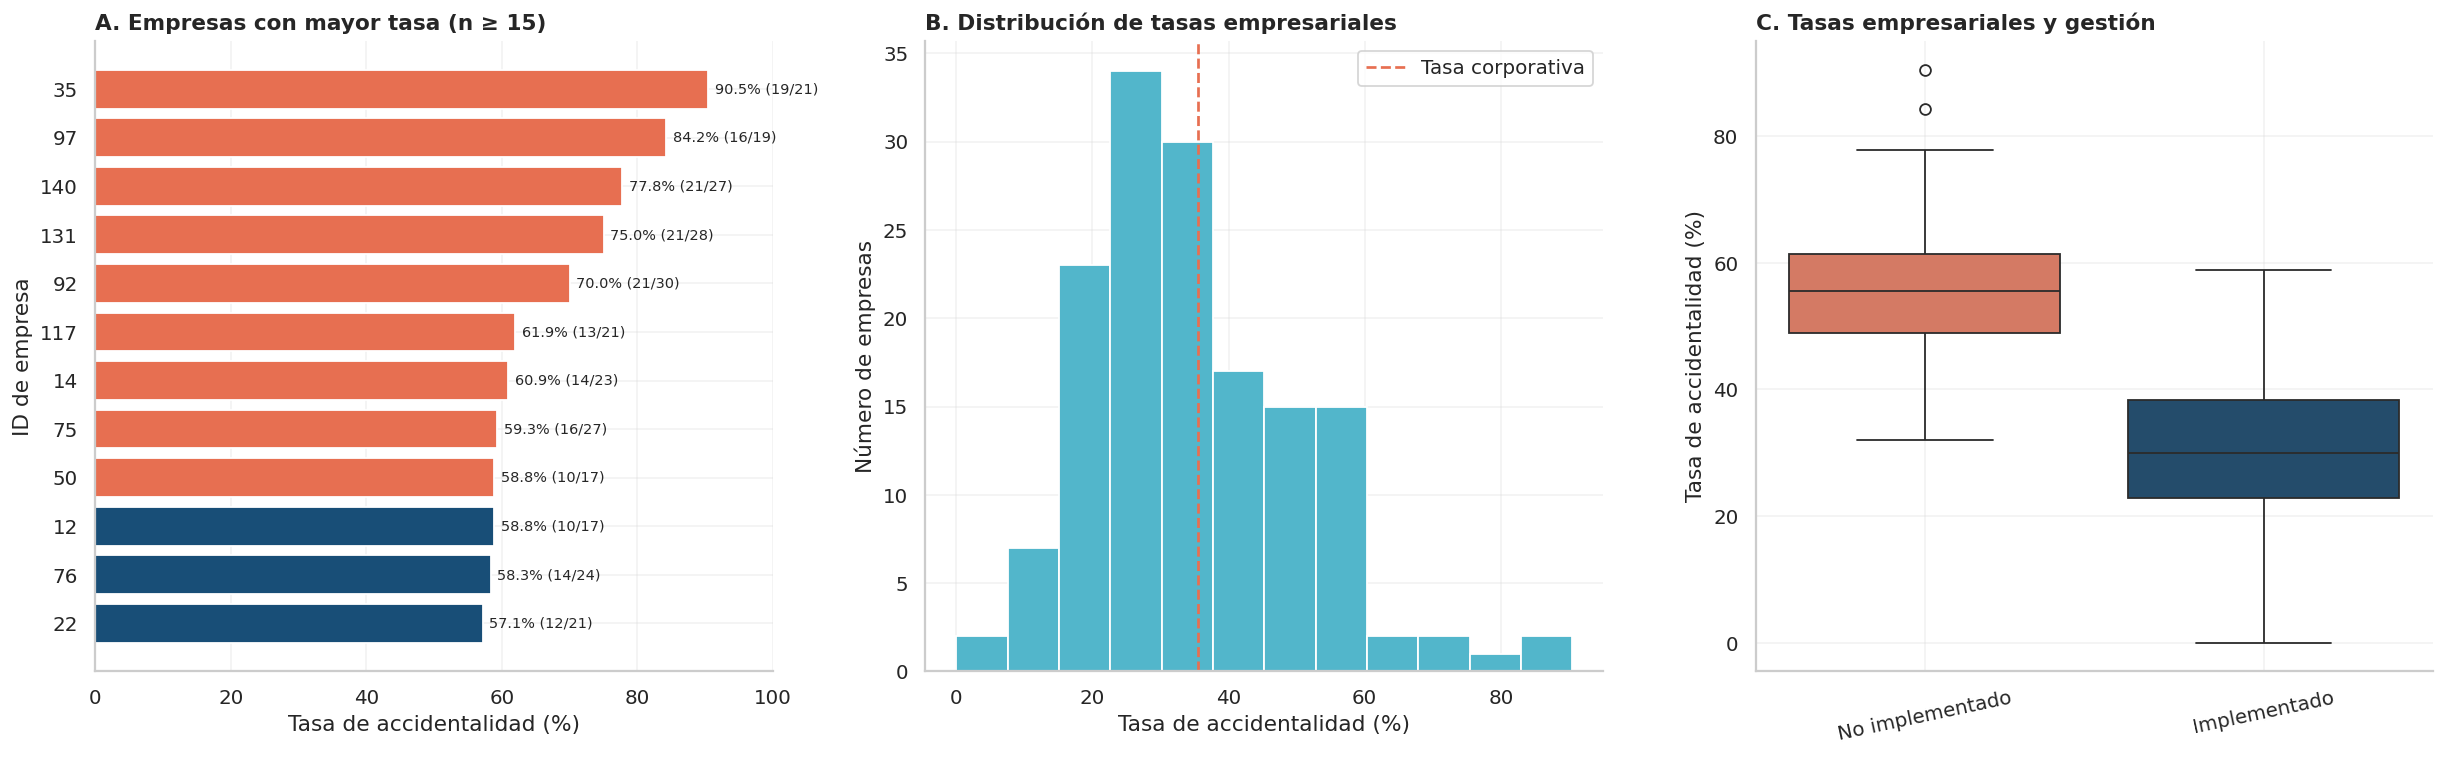

In [11]:
tabla_empresas = (
    df_final.groupby(["id_empresa", "sector_economico", "sistema_gestion"], observed=True)
    .agg(trabajadores=("id_trabajador", "nunique"), accidentados=("incidente", "sum"))
    .reset_index()
)
tabla_empresas["tasa_pct"] = 100 * tabla_empresas["accidentados"] / tabla_empresas["trabajadores"]
tabla_empresas["sistema_gestion"] = tabla_empresas["sistema_gestion"].map({0: "No implementado", 1: "Implementado"})
ranking_empresas = (
    tabla_empresas.loc[tabla_empresas["trabajadores"].ge(15)]
    .sort_values(["tasa_pct", "accidentados"], ascending=False)
    .head(15).reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
ranking_plot = ranking_empresas.head(12).sort_values("tasa_pct")
colores_ranking = ranking_plot["sistema_gestion"].map({"No implementado": COLORES["rojo"], "Implementado": COLORES["azul"]})
barras = axes[0].barh(ranking_plot["id_empresa"].astype(str), ranking_plot["tasa_pct"], color=colores_ranking)
axes[0].set_title("A. Empresas con mayor tasa (n ≥ 15)", loc="left", fontweight="bold")
axes[0].set_xlabel("Tasa de accidentalidad (%)")
axes[0].set_ylabel("ID de empresa")
for barra, (_, fila) in zip(barras, ranking_plot.iterrows()):
    axes[0].text(barra.get_width()+1, barra.get_y()+barra.get_height()/2,
                 f"{fila['tasa_pct']:.1f}% ({int(fila['accidentados'])}/{int(fila['trabajadores'])})",
                 va="center", fontsize=8)
axes[0].set_xlim(0, 100)

axes[1].hist(tabla_empresas["tasa_pct"], bins=12, color=COLORES["azul_claro"], edgecolor="white")
axes[1].axvline(df_final["incidente"].mean()*100, color=COLORES["rojo"], linestyle="--", label="Tasa corporativa")
axes[1].set_title("B. Distribución de tasas empresariales", loc="left", fontweight="bold")
axes[1].set_xlabel("Tasa de accidentalidad (%)")
axes[1].set_ylabel("Número de empresas")
axes[1].legend()

sns.boxplot(
    data=tabla_empresas, x="sistema_gestion", y="tasa_pct",
    order=["No implementado", "Implementado"],
    hue="sistema_gestion", hue_order=["No implementado", "Implementado"],
    legend=False, palette=["#E76F51", "#184E77"], ax=axes[2]
)
axes[2].set_title("C. Tasas empresariales y gestión", loc="left", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Tasa de accidentalidad (%)")
axes[2].tick_params(axis="x", rotation=12)

for ax in axes:
    ax.grid(alpha=0.22)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()
display(ranking_empresas)

Las empresas 35 (90,48%; 19/21), 97 (84,21%; 16/19) y 140 (77,78%; 21/27) lideran el ranking; carecen de sistema de gestión y pertenecen a minería o construcción. El ranking debe activar auditorías, no sanciones automáticas.

## 6. Análisis solicitado - accidentalidad nocturna por nivel educativo y sector económico

Se filtran exclusivamente los **685 trabajadores nocturnos** y se calculan dos tablas comparables. La etiqueta de cada barra muestra **tasa (accidentados/trabajadores expuestos)**.

In [12]:
df_noche = df_final.loc[df_final["jornada"].eq("nocturna")].copy()
tabla_noche_nivel = tabla_riesgo(df_noche, "nivel_educativo")
tabla_noche_sector = tabla_riesgo(df_noche, "sector_economico")

print(f"Trabajadores nocturnos: {len(df_noche):,} | Accidentados: {df_noche['incidente'].sum():,} | Tasa: {df_noche['incidente'].mean()*100:.2f}%")
mostrar_tabla(tabla_noche_nivel, "Accidentalidad nocturna por nivel educativo")
mostrar_tabla(tabla_noche_sector, "Accidentalidad nocturna por sector económico")

Trabajadores nocturnos: 685 | Accidentados: 308 | Tasa: 44.96%
Accidentalidad nocturna por nivel educativo
Accidentalidad nocturna por sector económico


,nivel_educativo,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,tecnico,326,157,157,48.16%,50.97%,42.79%,53.57%
1,bachiller,241,107,107,44.40%,34.74%,38.26%,50.71%
2,maestria,15,6,6,40.00%,1.95%,19.82%,64.25%
3,universitario,84,33,33,39.29%,10.71%,29.53%,49.98%
4,especializacion,19,5,5,26.32%,1.62%,11.81%,48.79%


,sector_economico,trabajadores,accidentados,accidentes,tasa_pct,participacion_accidentes_pct,ic95_inf,ic95_sup
0,mineria,64,42,42,65.62%,13.64%,53.40%,76.08%
1,construccion,136,79,79,58.09%,25.65%,49.68%,66.05%
2,comercio,43,20,20,46.51%,6.49%,32.51%,61.08%
3,manufactura,89,40,40,44.94%,12.99%,35.03%,55.27%
4,agricultura,80,31,31,38.75%,10.06%,28.82%,49.71%
5,servicios,78,30,30,38.46%,9.74%,28.45%,49.56%
6,educacion,29,11,11,37.93%,3.57%,22.69%,56.00%
7,funcion publica,24,9,9,37.50%,2.92%,21.16%,57.29%
8,alimentos,101,33,33,32.67%,10.71%,24.31%,42.31%
9,salud,41,13,13,31.71%,4.22%,19.56%,46.98%


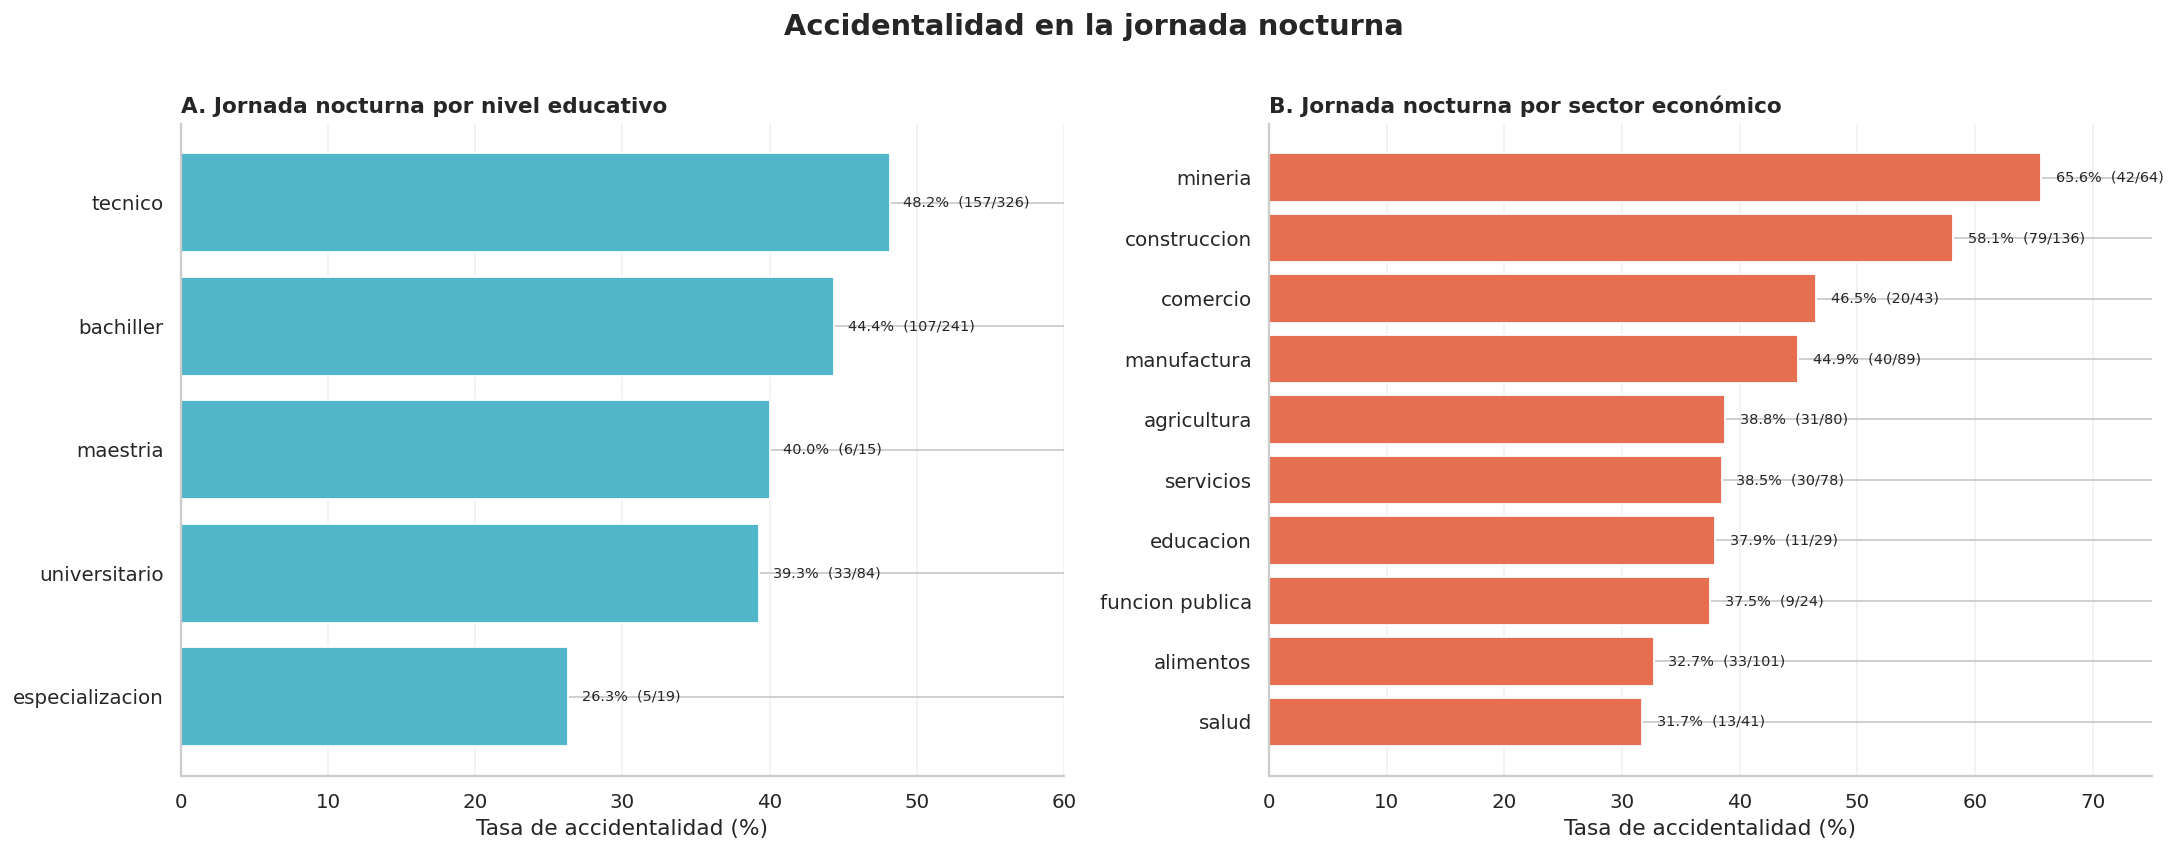

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
grafica_tasa(
    axes[0], tabla_noche_nivel, "nivel_educativo",
    "A. Jornada nocturna por nivel educativo",
    horizontal=True, color=COLORES["azul_claro"]
)
grafica_tasa(
    axes[1], tabla_noche_sector, "sector_economico",
    "B. Jornada nocturna por sector económico",
    horizontal=True, color=COLORES["rojo"]
)
axes[0].set_xlim(0, 60)
axes[1].set_xlim(0, 75)
plt.suptitle("Accidentalidad en la jornada nocturna", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

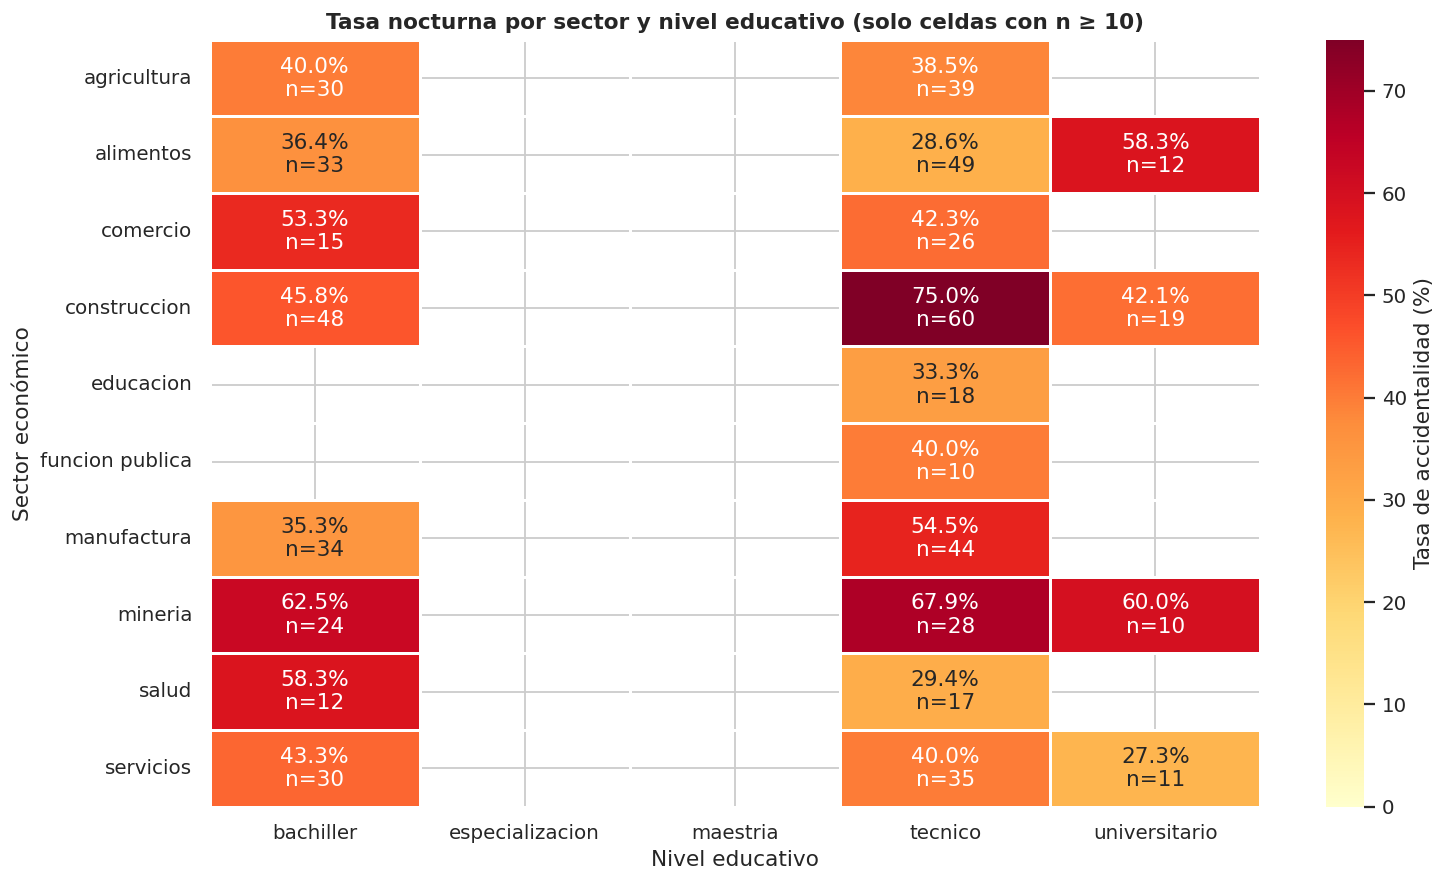

In [14]:
# Cruce sector × nivel educativo en la noche.
# Se ocultan celdas con menos de 10 trabajadores para evitar interpretar tasas inestables.
cruce = (
    df_noche.groupby(["sector_economico", "nivel_educativo"], observed=True)
    .agg(trabajadores=("id_trabajador", "nunique"), accidentados=("incidente", "sum"))
    .reset_index()
)
cruce["tasa_pct"] = 100 * cruce["accidentados"] / cruce["trabajadores"]

tasas = cruce.pivot(index="sector_economico", columns="nivel_educativo", values="tasa_pct")
conteos = cruce.pivot(index="sector_economico", columns="nivel_educativo", values="trabajadores")
mascara = conteos.lt(10) | tasas.isna()

anotaciones = tasas.copy().astype(object)
for fila in tasas.index:
    for columna in tasas.columns:
        if pd.isna(tasas.loc[fila, columna]) or conteos.loc[fila, columna] < 10:
            anotaciones.loc[fila, columna] = ""
        else:
            anotaciones.loc[fila, columna] = f"{tasas.loc[fila, columna]:.1f}%\nn={int(conteos.loc[fila, columna])}"

plt.figure(figsize=(12, 7))
sns.heatmap(
    tasas,
    mask=mascara,
    annot=anotaciones,
    fmt="",
    cmap="YlOrRd",
    vmin=0,
    vmax=75,
    linewidths=0.6,
    cbar_kws={"label": "Tasa de accidentalidad (%)"},
)
plt.title("Tasa nocturna por sector y nivel educativo (solo celdas con n ≥ 10)", fontweight="bold")
plt.xlabel("Nivel educativo")
plt.ylabel("Sector económico")
plt.tight_layout()
plt.show()

### Interpretación del análisis nocturno

- **Nivel educativo:** técnico registra **157 casos de 326 trabajadores (48,16%)**; bachiller, **107 de 241 (44,40%)**. El nivel técnico es el principal foco por tasa y volumen, aunque la prueba global entre niveles no evidencia una diferencia estadísticamente concluyente (`p = 0,259`).
- **Sector económico:** minería tiene la mayor tasa (**65,62%; 42/64**). Construcción ocupa el segundo lugar en tasa (**58,09%**) y el primero en volumen nocturno (**79 casos de 136 trabajadores**). En este filtro, el sector sí muestra una asociación clara con la accidentalidad (`p < 0,001`).
- Las celdas con muy pocos trabajadores pueden producir tasas extremas; por eso el mapa de calor oculta combinaciones con `n < 10`.

### 6.1 Matrices sectoriales y perfiles combinados

Las matrices muestran dónde se concentran las tasas. El perfil multivariable solo conserva grupos con al menos 20 trabajadores.

,sector_economico,jornada,tipo_cargo,trabajadores,accidentados,tasa_pct
0,mineria,nocturna,operativo,49,31,63.27
1,construccion,nocturna,operativo,112,69,61.61
2,mineria,mixta,operativo,38,19,50.00
3,comercio,nocturna,operativo,32,16,50.00
4,construccion,mixta,administrativo,25,12,48.00
5,manufactura,nocturna,operativo,63,30,47.62
6,construccion,diurna,operativo,311,148,47.59
7,construccion,mixta,operativo,89,42,47.19
8,servicios,nocturna,operativo,57,26,45.61
9,construccion,nocturna,administrativo,24,10,41.67


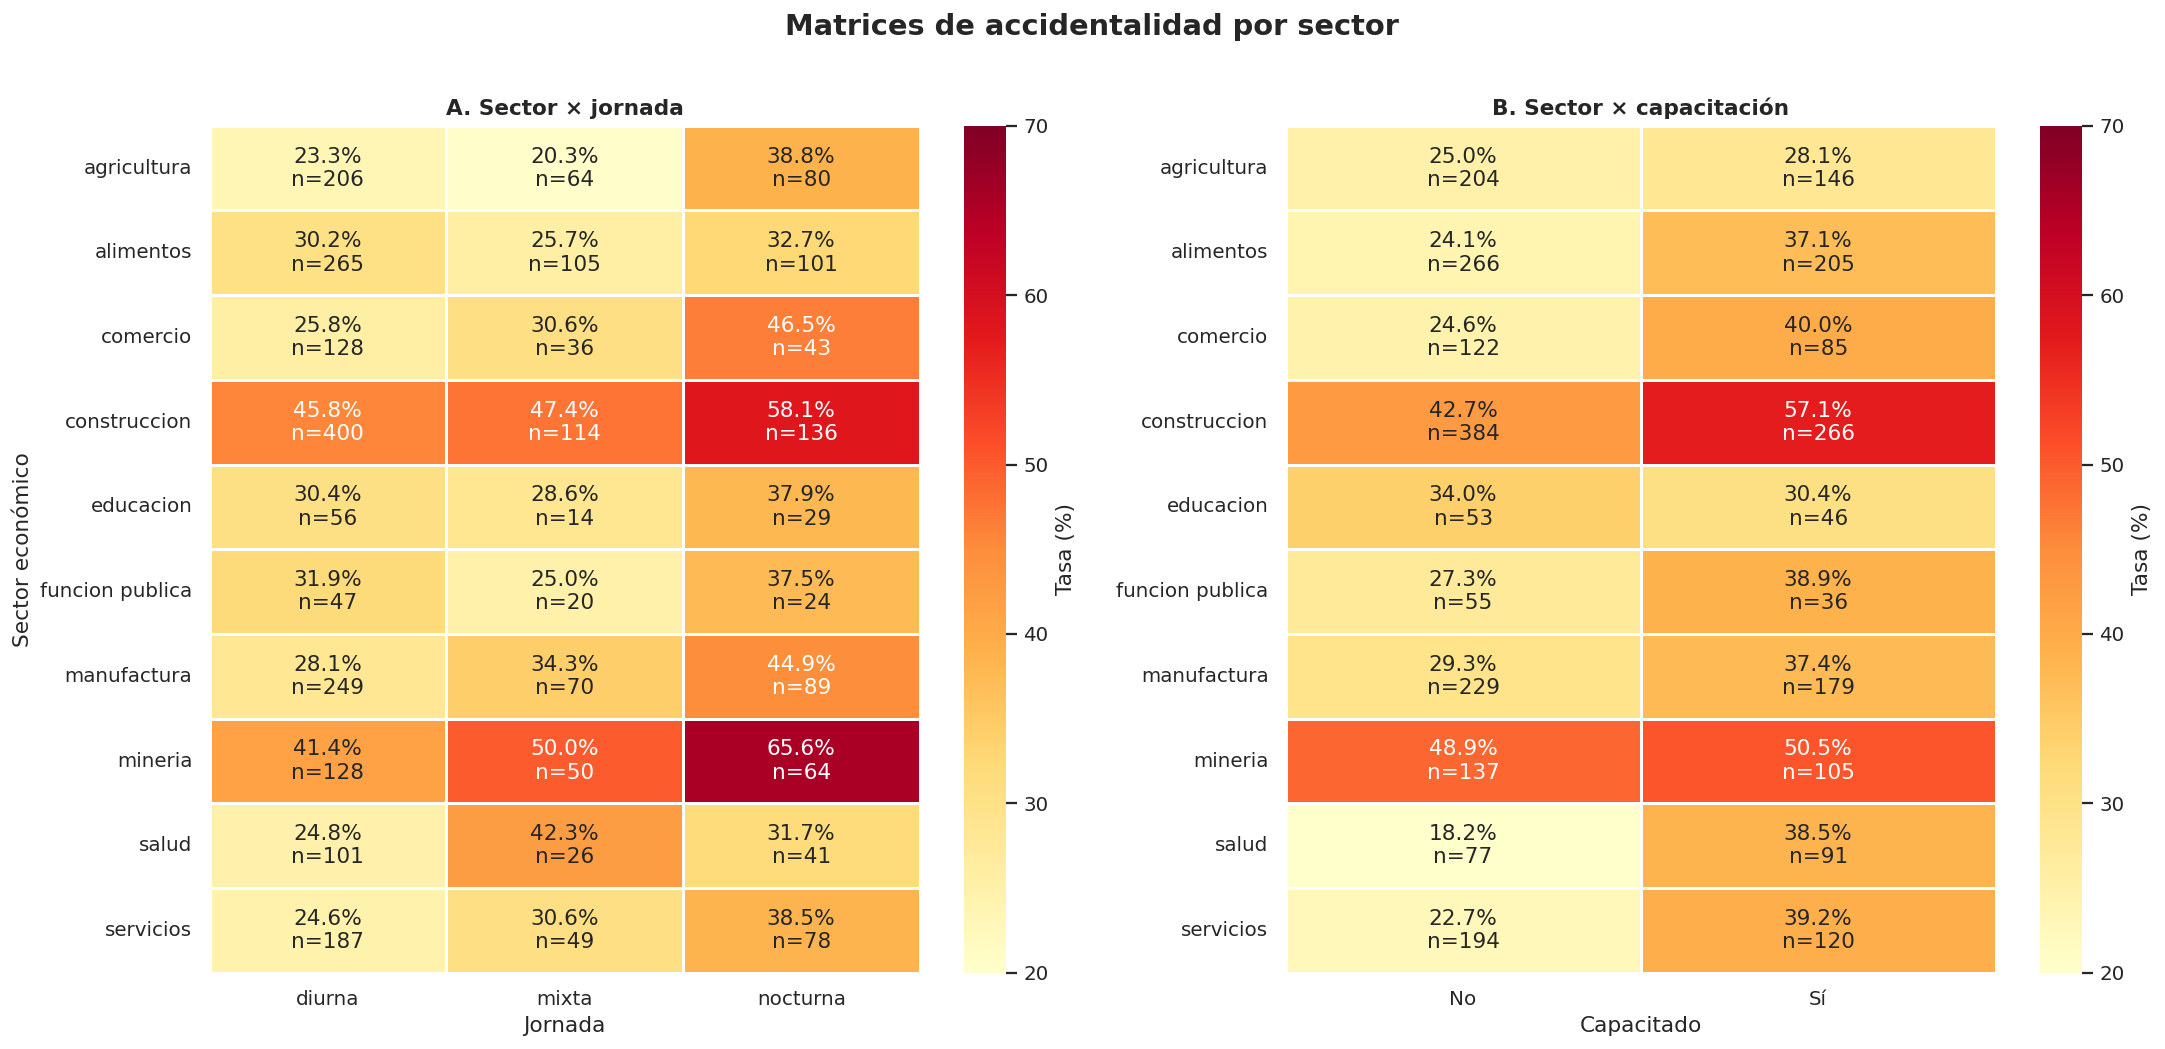

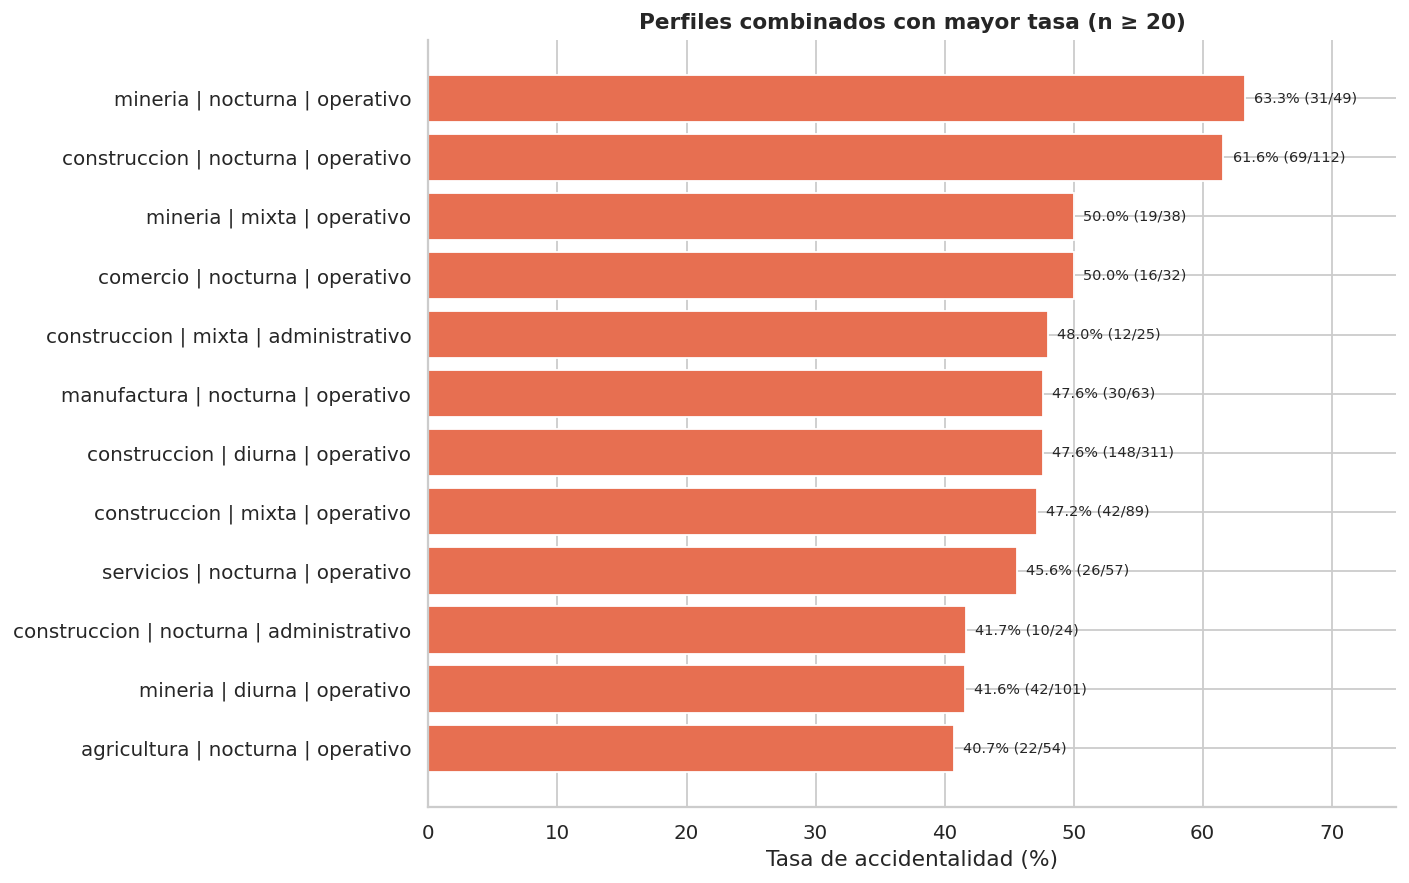

In [15]:
def matriz_tasa_y_n(datos, filas, columnas):
    resumen = (
        datos.groupby([filas, columnas], observed=True)
        .agg(trabajadores=("id_trabajador", "nunique"), accidentados=("incidente", "sum"))
        .reset_index()
    )
    resumen["tasa_pct"] = 100 * resumen["accidentados"] / resumen["trabajadores"]
    tasas = resumen.pivot(index=filas, columns=columnas, values="tasa_pct")
    n = resumen.pivot(index=filas, columns=columnas, values="trabajadores")
    anot = tasas.copy().astype(object)
    for fila in tasas.index:
        for col in tasas.columns:
            anot.loc[fila, col] = f"{tasas.loc[fila, col]:.1f}%\nn={int(n.loc[fila, col])}"
    return tasas, n, anot


tasas_js, n_js, anot_js = matriz_tasa_y_n(df_final, "sector_economico", "jornada")
df_cap_label = df_final.assign(capacitacion=df_final["capacitado"].map({0: "No", 1: "Sí"}))
tasas_cs, n_cs, anot_cs = matriz_tasa_y_n(df_cap_label, "sector_economico", "capacitacion")

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
sns.heatmap(
    tasas_js[["diurna", "mixta", "nocturna"]], annot=anot_js[["diurna", "mixta", "nocturna"]],
    fmt="", cmap="YlOrRd", vmin=20, vmax=70, linewidths=0.6,
    cbar_kws={"label": "Tasa (%)"}, ax=axes[0]
)
axes[0].set_title("A. Sector × jornada", fontweight="bold")
axes[0].set_xlabel("Jornada")
axes[0].set_ylabel("Sector económico")

sns.heatmap(
    tasas_cs[["No", "Sí"]], annot=anot_cs[["No", "Sí"]], fmt="",
    cmap="YlOrRd", vmin=20, vmax=70, linewidths=0.6,
    cbar_kws={"label": "Tasa (%)"}, ax=axes[1]
)
axes[1].set_title("B. Sector × capacitación", fontweight="bold")
axes[1].set_xlabel("Capacitado")
axes[1].set_ylabel("")
plt.suptitle("Matrices de accidentalidad por sector", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

perfil_riesgo = (
    df_final.groupby(["sector_economico", "jornada", "tipo_cargo"], observed=True)
    .agg(trabajadores=("id_trabajador", "nunique"), accidentados=("incidente", "sum"))
    .reset_index()
)
perfil_riesgo["tasa_pct"] = 100 * perfil_riesgo["accidentados"] / perfil_riesgo["trabajadores"]
perfil_riesgo = (
    perfil_riesgo.loc[perfil_riesgo["trabajadores"].ge(20)]
    .sort_values(["tasa_pct", "accidentados"], ascending=False).reset_index(drop=True)
)
perfil_riesgo["perfil"] = perfil_riesgo["sector_economico"] + " | " + perfil_riesgo["jornada"] + " | " + perfil_riesgo["tipo_cargo"]

top_perfiles = perfil_riesgo.head(12).sort_values("tasa_pct")
plt.figure(figsize=(11, 7))
barras = plt.barh(top_perfiles["perfil"], top_perfiles["tasa_pct"], color=COLORES["rojo"])
plt.title("Perfiles combinados con mayor tasa (n ≥ 20)", fontweight="bold")
plt.xlabel("Tasa de accidentalidad (%)")
for barra, (_, fila) in zip(barras, top_perfiles.iterrows()):
    plt.text(barra.get_width()+0.7, barra.get_y()+barra.get_height()/2,
             f"{fila['tasa_pct']:.1f}% ({int(fila['accidentados'])}/{int(fila['trabajadores'])})",
             va="center", fontsize=8)
plt.xlim(0, 75)
sns.despine()
plt.tight_layout()
plt.show()
display(perfil_riesgo.head(15)[["sector_economico", "jornada", "tipo_cargo", "trabajadores", "accidentados", "tasa_pct"]])

El perfil de mayor tasa con muestra suficiente es operativo nocturno en minería: 63,27% (31/49), seguido de operativo nocturno en construcción: 61,61% (69/112). Esto respalda una regla ERP centrada en la exposición laboral real.

## 7. Consecuencias del accidente - partes del cuerpo y lesiones

,parte_del_cuerpo,accidentes,participacion_pct
0,mano,239,22.40%
1,pie,209,19.59%
2,abdomen,201,18.84%
3,espalda,132,12.37%
4,cabeza,130,12.18%
5,ojo,86,8.06%
6,torax,70,6.56%


,lesion,accidentes,participacion_pct
0,fractura,316,29.62%
1,lesiones multiples,211,19.78%
2,trauma superficial,160,15.00%
3,luxacion,157,14.71%
4,herida,142,13.31%
5,esqguince,81,7.59%


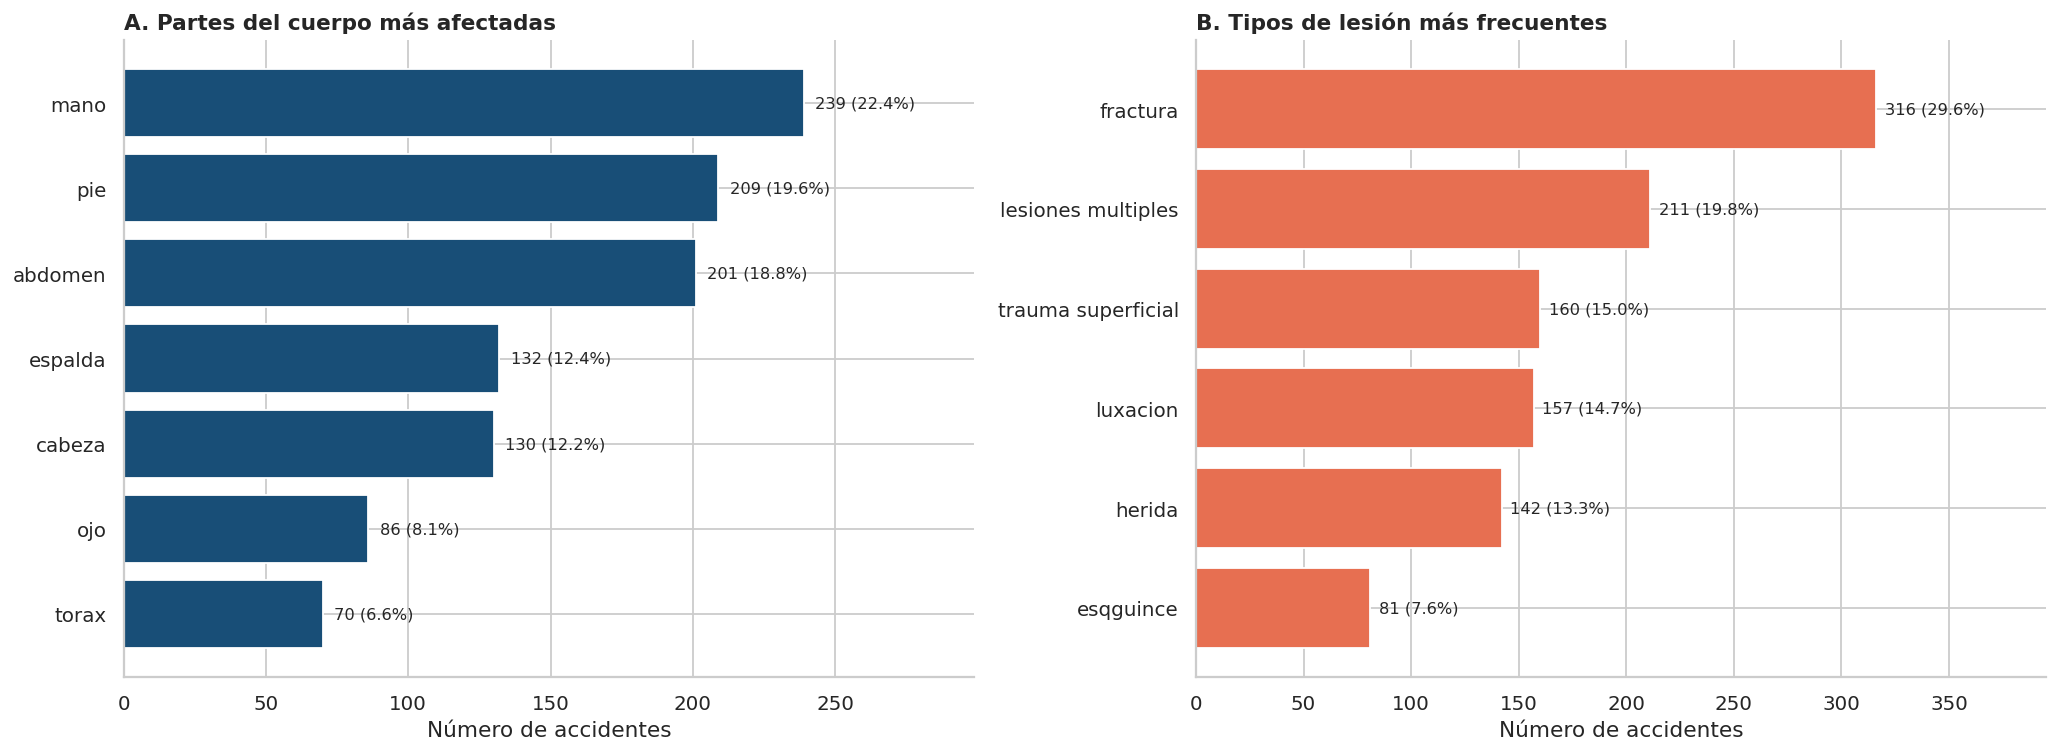

In [16]:
df_incidentes = df_final.loc[df_final["incidente"].eq(1)].copy()

tabla_cuerpo = (
    df_incidentes["parte_del_cuerpo"].value_counts()
    .rename_axis("parte_del_cuerpo").reset_index(name="accidentes")
)
tabla_cuerpo["participacion_pct"] = 100 * tabla_cuerpo["accidentes"] / tabla_cuerpo["accidentes"].sum()

tabla_lesion = (
    df_incidentes["lesion"].value_counts()
    .rename_axis("lesion").reset_index(name="accidentes")
)
tabla_lesion["participacion_pct"] = 100 * tabla_lesion["accidentes"] / tabla_lesion["accidentes"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, tabla, categoria, titulo, color in [
    (axes[0], tabla_cuerpo, "parte_del_cuerpo", "A. Partes del cuerpo más afectadas", COLORES["azul"]),
    (axes[1], tabla_lesion, "lesion", "B. Tipos de lesión más frecuentes", COLORES["rojo"]),
]:
    datos = tabla.sort_values("accidentes", ascending=True)
    barras = ax.barh(datos[categoria], datos["accidentes"], color=color)
    ax.set_title(titulo, loc="left", fontweight="bold")
    ax.set_xlabel("Número de accidentes")
    for barra, (_, fila) in zip(barras, datos.iterrows()):
        ax.text(barra.get_width()+4, barra.get_y()+barra.get_height()/2, f"{int(fila['accidentes'])} ({fila['participacion_pct']:.1f}%)", va="center", fontsize=9)
    ax.set_xlim(0, datos["accidentes"].max()*1.25)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

tabla_cuerpo_mostrar = tabla_cuerpo.copy()
tabla_lesion_mostrar = tabla_lesion.copy()
tabla_cuerpo_mostrar["participacion_pct"] = tabla_cuerpo_mostrar["participacion_pct"].map(lambda x: f"{x:.2f}%")
tabla_lesion_mostrar["participacion_pct"] = tabla_lesion_mostrar["participacion_pct"].map(lambda x: f"{x:.2f}%")
display(tabla_cuerpo_mostrar)
display(tabla_lesion_mostrar)

Las **manos** son la parte más afectada (**239 casos; 22,40%**) y las **fracturas** el tipo de lesión más frecuente (**316; 29,62%**). El ERP debería vincular estos resultados con la matriz de peligros por tarea para exigir controles de ingeniería, resguardos y EPP específico antes del turno.

### 7.1 Lesiones según jornada y cargo

Los porcentajes se calculan dentro de las personas accidentadas de cada jornada o cargo. Describen la composición del daño, no la probabilidad de accidentarse.

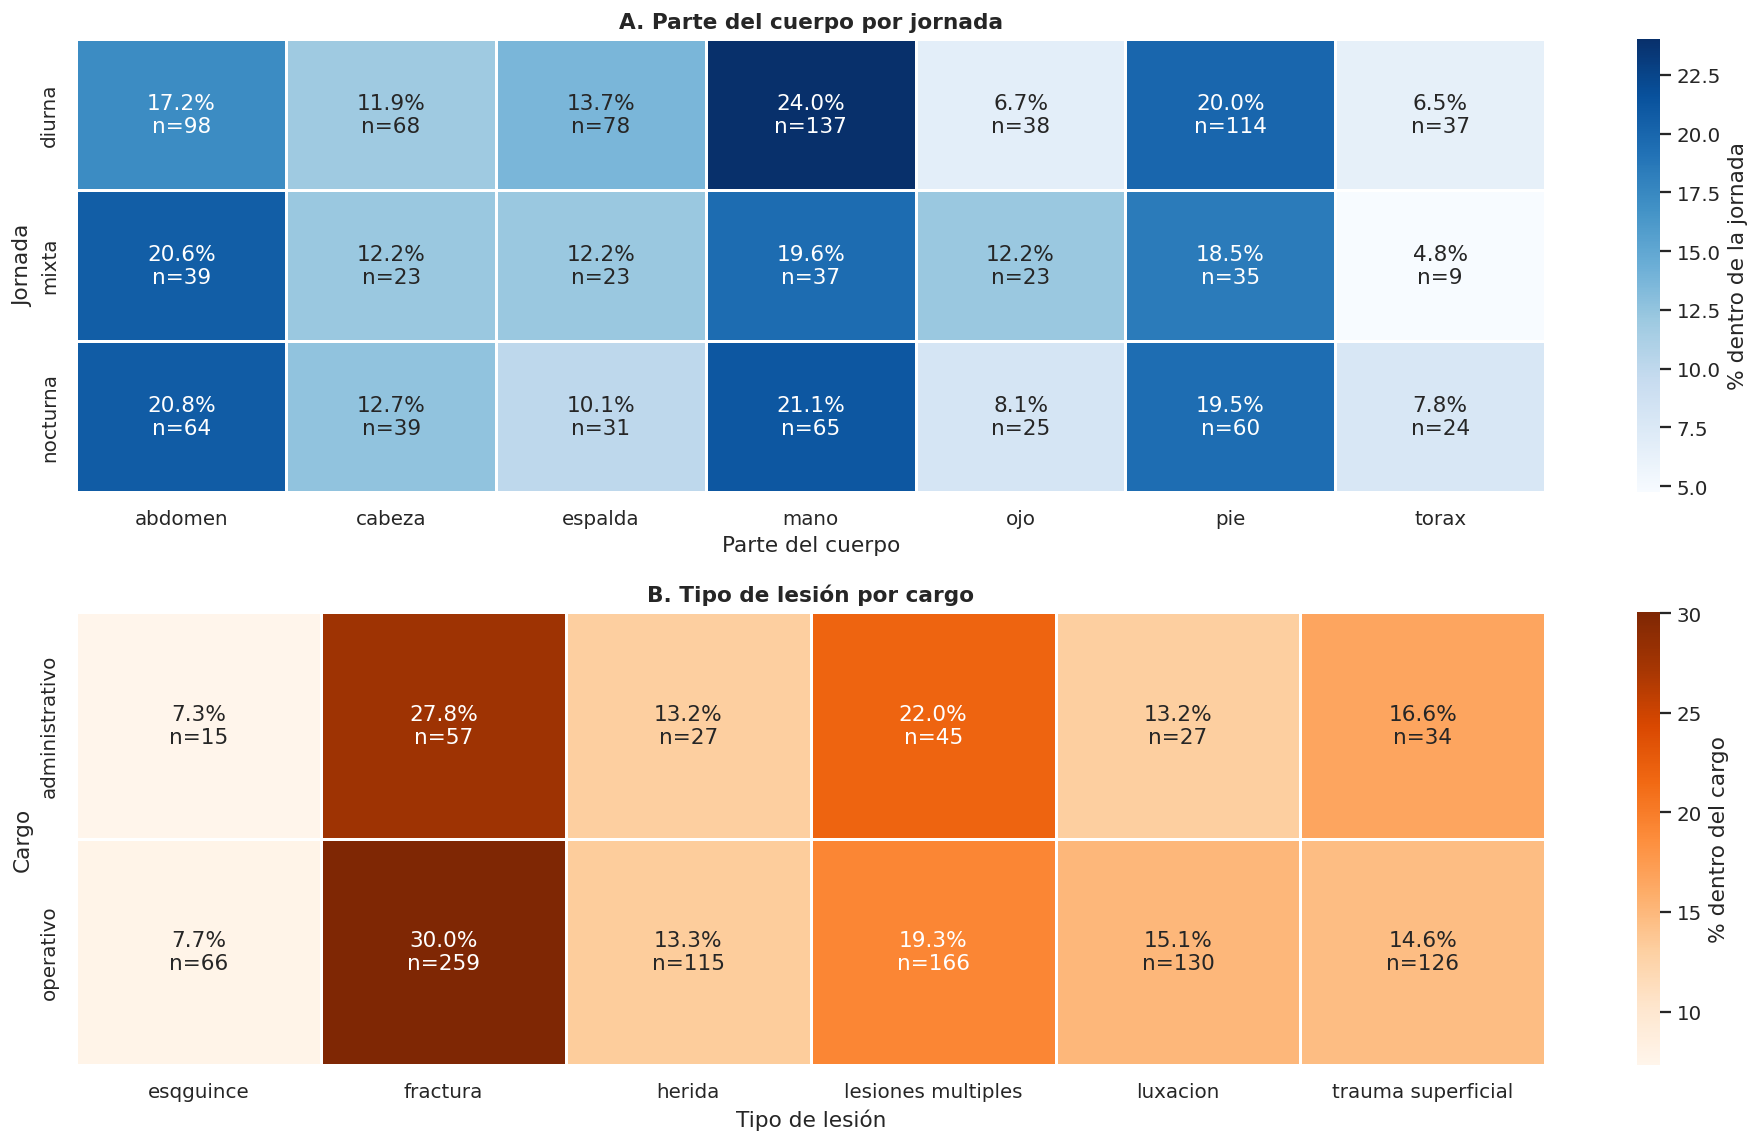

In [17]:
porc_cuerpo_jornada = pd.crosstab(df_incidentes["jornada"], df_incidentes["parte_del_cuerpo"], normalize="index") * 100
cont_cuerpo_jornada = pd.crosstab(df_incidentes["jornada"], df_incidentes["parte_del_cuerpo"])
porc_lesion_cargo = pd.crosstab(df_incidentes["tipo_cargo"], df_incidentes["lesion"], normalize="index") * 100
cont_lesion_cargo = pd.crosstab(df_incidentes["tipo_cargo"], df_incidentes["lesion"])

anot_cuerpo = porc_cuerpo_jornada.copy().astype(object)
for fila in porc_cuerpo_jornada.index:
    for col in porc_cuerpo_jornada.columns:
        anot_cuerpo.loc[fila, col] = f"{porc_cuerpo_jornada.loc[fila, col]:.1f}%\nn={cont_cuerpo_jornada.loc[fila, col]}"

anot_lesion = porc_lesion_cargo.copy().astype(object)
for fila in porc_lesion_cargo.index:
    for col in porc_lesion_cargo.columns:
        anot_lesion.loc[fila, col] = f"{porc_lesion_cargo.loc[fila, col]:.1f}%\nn={cont_lesion_cargo.loc[fila, col]}"

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
sns.heatmap(
    porc_cuerpo_jornada, annot=anot_cuerpo, fmt="", cmap="Blues",
    linewidths=0.6, cbar_kws={"label": "% dentro de la jornada"}, ax=axes[0]
)
axes[0].set_title("A. Parte del cuerpo por jornada", fontweight="bold")
axes[0].set_xlabel("Parte del cuerpo")
axes[0].set_ylabel("Jornada")

sns.heatmap(
    porc_lesion_cargo, annot=anot_lesion, fmt="", cmap="Oranges",
    linewidths=0.6, cbar_kws={"label": "% dentro del cargo"}, ax=axes[1]
)
axes[1].set_title("B. Tipo de lesión por cargo", fontweight="bold")
axes[1].set_xlabel("Tipo de lesión")
axes[1].set_ylabel("Cargo")
plt.tight_layout()
plt.show()

Las manos son la parte afectada más frecuente en las tres jornadas y las fracturas lideran en cargos administrativos y operativos. Los operativos reúnen 259 fracturas debido a su mayor exposición y volumen de accidentes.

## 8. Validación estadística descriptiva

Se usa chi-cuadrado para verificar si las diferencias observadas son compatibles con una asociación entre cada variable categórica y el indicador de accidente. `V de Cramér` resume la intensidad de la asociación (0 = nula; valores mayores = asociación más fuerte). Esta validación no transforma el estudio en causal.

In [18]:
def asociacion_chi2(datos, variable):
    contingencia = pd.crosstab(datos[variable], datos["incidente"])
    chi2, p_valor, gl, esperadas = chi2_contingency(contingencia)
    n = contingencia.to_numpy().sum()
    minimo = min(contingencia.shape[0] - 1, contingencia.shape[1] - 1)
    v_cramer = math.sqrt(chi2 / (n * minimo)) if minimo > 0 else np.nan
    return {
        "variable": variable,
        "chi2": chi2,
        "grados_libertad": gl,
        "p_valor": p_valor,
        "v_cramer": v_cramer,
        "frecuencia_esperada_min": esperadas.min(),
    }

variables = [
    "jornada", "capacitado", "sector_economico", "sistema_gestion",
    "nivel_educativo", "tipo_cargo", "genero", "tipo_empresa"
]
tabla_asociacion = pd.DataFrame([asociacion_chi2(df_final, v) for v in variables])
tabla_asociacion = tabla_asociacion.sort_values("v_cramer", ascending=False).reset_index(drop=True)

tabla_asociacion_mostrar = tabla_asociacion.copy()
tabla_asociacion_mostrar["chi2"] = tabla_asociacion_mostrar["chi2"].map(lambda x: f"{x:.2f}")
tabla_asociacion_mostrar["p_valor"] = tabla_asociacion_mostrar["p_valor"].map(lambda x: f"{x:.4g}")
tabla_asociacion_mostrar["v_cramer"] = tabla_asociacion_mostrar["v_cramer"].map(lambda x: f"{x:.3f}")
tabla_asociacion_mostrar["frecuencia_esperada_min"] = tabla_asociacion_mostrar["frecuencia_esperada_min"].map(lambda x: f"{x:.1f}")
display(tabla_asociacion_mostrar)

print("Asociaciones nocturnas solicitadas:")
tabla_asociacion_noche = pd.DataFrame([
    asociacion_chi2(df_noche, "nivel_educativo"),
    asociacion_chi2(df_noche, "sector_economico"),
    asociacion_chi2(df_noche, "capacitado"),
])
tabla_asociacion_noche["chi2"] = tabla_asociacion_noche["chi2"].map(lambda x: f"{x:.2f}")
tabla_asociacion_noche["p_valor"] = tabla_asociacion_noche["p_valor"].map(lambda x: f"{x:.4g}")
tabla_asociacion_noche["v_cramer"] = tabla_asociacion_noche["v_cramer"].map(lambda x: f"{x:.3f}")
tabla_asociacion_noche["frecuencia_esperada_min"] = tabla_asociacion_noche["frecuencia_esperada_min"].map(lambda x: f"{x:.1f}")
display(tabla_asociacion_noche)

Asociaciones nocturnas solicitadas:


,variable,chi2,grados_libertad,p_valor,v_cramer,frecuencia_esperada_min
0,sistema_gestion,127.75,1,1.27e-29,0.206,179.6
1,sector_economico,102.44,9,5.05e-18,0.185,32.4
2,capacitado,35.82,1,2.17e-09,0.109,454.9
3,jornada,35.11,2,2.374e-08,0.108,194.9
4,tipo_cargo,17.80,1,2.45e-05,0.077,252.5
5,nivel_educativo,2.33,4,0.6745,0.028,22.8
6,genero,1.36,1,0.2435,0.021,532.8
7,tipo_empresa,0.03,1,0.8554,0.003,112.0


,variable,chi2,grados_libertad,p_valor,v_cramer,frecuencia_esperada_min
0,nivel_educativo,5.29,4,0.2588,0.088,6.7
1,sector_economico,33.33,9,0.0001172,0.221,10.8
2,capacitado,9.25,1,0.002355,0.116,129.9


,variable,chi2,grados_libertad,p_valor,v_cramer,frecuencia_esperada_min
0,sistema_gestion,127.75,1,1.27e-29,0.206,179.6
1,sector_economico,102.44,9,5.05e-18,0.185,32.4
2,num_hijos,75.02,5,9.224e-15,0.158,11.0
3,grupo_edad,55.96,4,2.047e-11,0.137,170.0
4,capacitado,35.82,1,2.17e-09,0.109,454.9
5,jornada,35.11,2,2.374e-08,0.108,194.9
6,tipo_cargo,17.80,1,2.45e-05,0.077,252.5
7,nivel_educativo,2.33,4,0.6745,0.028,22.8
8,grupo_antiguedad,1.69,4,0.7933,0.024,31.3
9,genero,1.36,1,0.2435,0.021,532.8


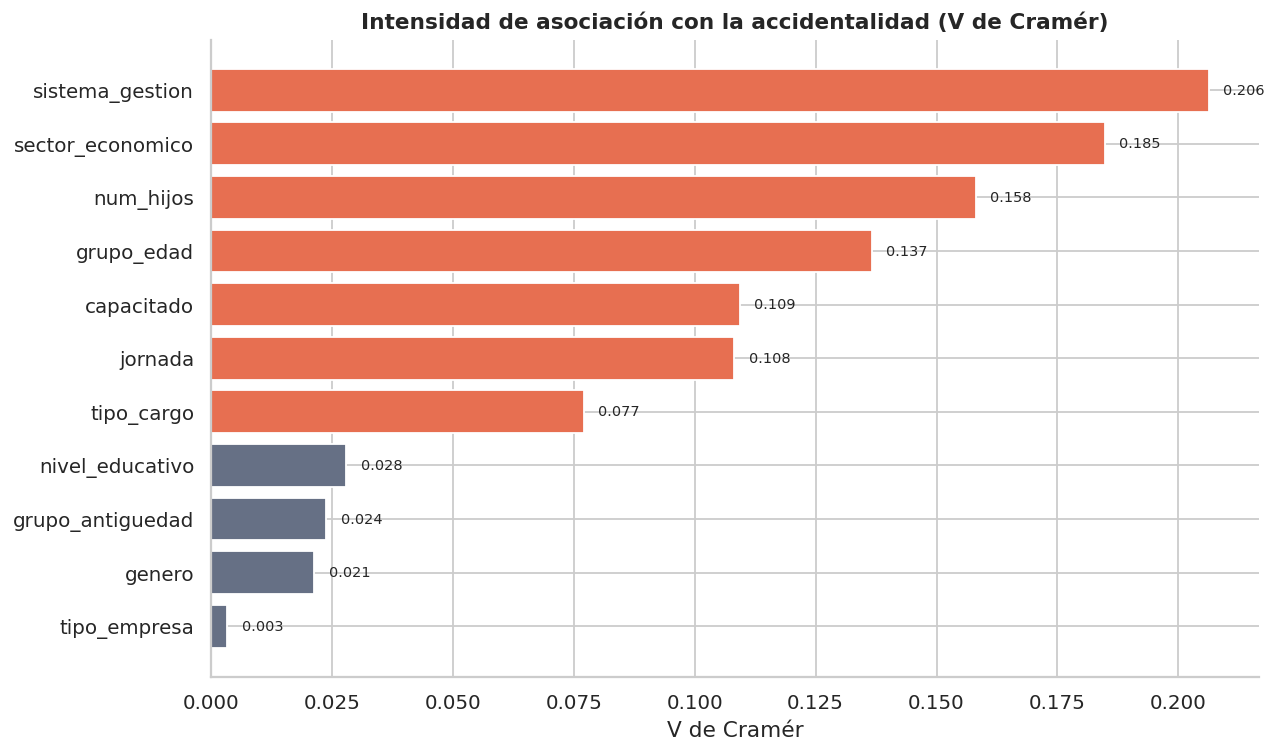

In [19]:
variables_ampliadas = [
    "sistema_gestion", "sector_economico", "num_hijos", "grupo_edad",
    "capacitado", "jornada", "tipo_cargo", "nivel_educativo",
    "grupo_antiguedad", "genero", "tipo_empresa"
]
tabla_asociacion_ampliada = pd.DataFrame(
    [asociacion_chi2(df_final, variable) for variable in variables_ampliadas]
).sort_values("v_cramer", ascending=False).reset_index(drop=True)

tabla_asociacion_mostrar = tabla_asociacion_ampliada.copy()
for columna, formato in {
    "chi2": "{:.2f}", "p_valor": "{:.4g}", "v_cramer": "{:.3f}", "frecuencia_esperada_min": "{:.1f}"
}.items():
    tabla_asociacion_mostrar[columna] = tabla_asociacion_mostrar[columna].map(lambda valor, f=formato: f.format(valor))
display(tabla_asociacion_mostrar)

plt.figure(figsize=(10, 6))
orden = tabla_asociacion_ampliada.sort_values("v_cramer")
colores = [COLORES["rojo"] if p < 0.05 else COLORES["gris"] for p in orden["p_valor"]]
plt.barh(orden["variable"], orden["v_cramer"], color=colores)
plt.title("Intensidad de asociación con la accidentalidad (V de Cramér)", fontweight="bold")
plt.xlabel("V de Cramér")
for indice, fila in orden.reset_index(drop=True).iterrows():
    plt.text(fila["v_cramer"]+0.003, indice, f"{fila['v_cramer']:.3f}", va="center", fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

## 9. Conclusiones integrales revisadas

1. La jornada nocturna es la más riesgosa: 44,96% (308/685), frente a 34,49% en mixta y 32,26% en diurna. La diurna acumula más casos por su mayor tamaño.
2. La capacitación registrada no demuestra reducción: 41,67% en capacitados vs 31,03% en no capacitados; en operativos nocturnos capacitados llega a 57,48%. No puede atribuirse causalidad.
3. Minería y construcción son prioritarias. En la noche alcanzan 65,62% y 58,09%; el perfil operativo nocturno llega a 63,27% en minería y 61,61% en construcción.
4. El sistema de gestión presenta la asociación organizacional más fuerte: 57,62% sin implementación vs 31,10% con sistema. Las empresas 35, 97 y 140 lideran el ranking y carecen de sistema.
5. Los operativos concentran 862 accidentados y una tasa de 37,64%. El grupo de 18 a 24 años registra 47,34%.
6. El nivel técnico lidera el riesgo nocturno por tasa y volumen (48,16%; 157/326), pero las diferencias por educación no son concluyentes.
7. Género, antigüedad y tipo de empresa no muestran asociaciones relevantes. La relación observada con número de hijos no debe usarse para decisiones automatizadas.
8. Manos y fracturas son las consecuencias dominantes: 239 lesiones en manos y 316 fracturas; los operativos reúnen 259 fracturas.
9. Los resultados son descriptivos. Faltan horas trabajadas, fechas, gravedad, incapacidad, tarea, peligro, uso de EPP y trazabilidad de capacitación.

## 10. Recomendaciones y regla de negocio ERP

### Regla automática prioritaria

SI jornada = nocturna, sector económico pertenece a minería o construcción y tipo de cargo = operativo, entonces clasificar la asignación como RIESGO CRÍTICO. Antes de confirmar el turno, validar certificación específica, competencia práctica, checklist de tarea y EPP, control de fatiga y aprobación del supervisor SST. Si falta cualquier control, bloquear la asignación y generar una alerta.

### Recomendaciones finales

1. Medir la efectividad de la capacitación con fecha, contenido, peligro cubierto, prueba práctica y comparación antes/después.
2. Auditar primero las empresas 35, 97 y 140 y gestionar planes correctivos con responsables y fechas en el ERP.
3. Reforzar iluminación, pausas, rotación, supervisión y controles de ingeniería en turnos nocturnos de minería y construcción.
4. Proteger a operativos jóvenes mediante inducción reforzada, acompañamiento y autorización por competencia.
5. Prevenir lesiones de manos y fracturas con resguardos, bloqueo-etiquetado, ayudas mecánicas y EPP según la matriz de peligros.
6. No usar género, edad, educación, número de hijos o tipo de empresa como criterios automáticos de exclusión.
7. Crear un tablero mensual con tasa por 100 expuestos, número de casos, gravedad e incapacidad; investigar segmentos que superen 44,96% o aumenten 5 puntos.